# Breast Cancer Classification with Soft-Voting Ensemble and Multi-Layer XAI
### Revised Version — Addressing Reviewer Comments (PONE-D-26-11640)

**Key revisions:**
- 12 models (added CatBoost, TabNet, MLP, Extra Trees)
- Leak-free pipeline: split first, engineer/scale on train only
- Probability calibration (Platt scaling) for tree models
- Comprehensive statistical tests: Friedman, McNemar, DeLong, Wilcoxon, Bonferroni/FDR
- ALE via manual implementation (no alibi dependency)
- LIME stability analysis (10 runs) + misclassified/borderline case analysis
- Extended clinical metrics: Specificity, NPV, FPR, FNR

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, time, subprocess
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score,
    f1_score, brier_score_loss
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats
from itertools import combinations

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# LightGBM
try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False

# CatBoost
try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    subprocess.run(["pip", "install", "catboost", "-q"])
    try:
        from catboost import CatBoostClassifier
        CATBOOST_AVAILABLE = True
    except:
        CATBOOST_AVAILABLE = False

# TabNet
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    import torch
    TABNET_AVAILABLE = True
except ImportError:
    subprocess.run(["pip", "install", "pytorch-tabnet", "-q"])
    try:
        from pytorch_tabnet.tab_model import TabNetClassifier
        import torch
        TABNET_AVAILABLE = True
    except:
        TABNET_AVAILABLE = False

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# LIME
try:
    from lime.lime_tabular import LimeTabularExplainer
    LIME_AVAILABLE = True
except ImportError:
    LIME_AVAILABLE = False

# ALE — manual implementation (no alibi dependency)
def compute_ale(model, X, feature_idx, n_bins=50):
    """
    1D Accumulated Local Effects. Corrects for feature correlations unlike PDP.
    Bins are quantile-based; local differences are accumulated and mean-centred.
    """
    X = np.array(X)
    feat_vals = X[:, feature_idx]
    quantiles = np.unique(np.percentile(feat_vals, np.linspace(0, 100, n_bins + 1)))
    ale_values, bin_centers = [], []
    for i in range(len(quantiles) - 1):
        lo, hi = quantiles[i], quantiles[i + 1]
        mask = (feat_vals >= lo) & (feat_vals <= hi)
        if mask.sum() == 0:
            continue
        X_lo = X[mask].copy(); X_lo[:, feature_idx] = lo
        X_hi = X[mask].copy(); X_hi[:, feature_idx] = hi
        delta = (model.predict_proba(X_hi)[:, 1] -
                 model.predict_proba(X_lo)[:, 1])
        ale_values.append(delta.mean())
        bin_centers.append((lo + hi) / 2)
    ale_values = np.array(ale_values)
    ale_values = np.cumsum(ale_values) - ale_values.mean()
    return np.array(bin_centers), ale_values

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 150
sns.set_palette("husl")

print("Setup complete.")
print(f"  XGBoost  : {XGBOOST_AVAILABLE}")
print(f"  LightGBM : {LIGHTGBM_AVAILABLE}")
print(f"  CatBoost : {CATBOOST_AVAILABLE}")
print(f"  TabNet   : {TABNET_AVAILABLE}")
print(f"  SHAP     : {SHAP_AVAILABLE}")
print(f"  LIME     : {LIME_AVAILABLE}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00
Setup complete.
  XGBoost  : True
  LightGBM : True
  CatBoost : True
  TabNet   : True
  SHAP     : True
  LIME     : True


## 2. Data Loading

In [2]:
try:
    df = pd.read_csv('/kaggle/input/datasets/uciml/breast-cancer-wisconsin-data/data.csv')
    print("Loaded from Kaggle input.")
except FileNotFoundError:
    try:
        df = pd.read_csv('data.csv')
        print("Loaded from local file.")
    except FileNotFoundError:
        print("ERROR: Place data.csv in the working directory.")
        raise

print(f"Shape: {df.shape}")
print(f"Columns (first 5): {df.columns.tolist()[:5]}")
print(df['diagnosis'].value_counts())

Loaded from Kaggle input.
Shape: (569, 33)
Columns (first 5): ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean']
diagnosis
B    357
M    212
Name: count, dtype: int64


## 3. Exploratory Data Analysis (EDA)

In [3]:
df.info()
print("\nMissing values:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['diagnosis'].value_counts(normalize=True).round(4))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

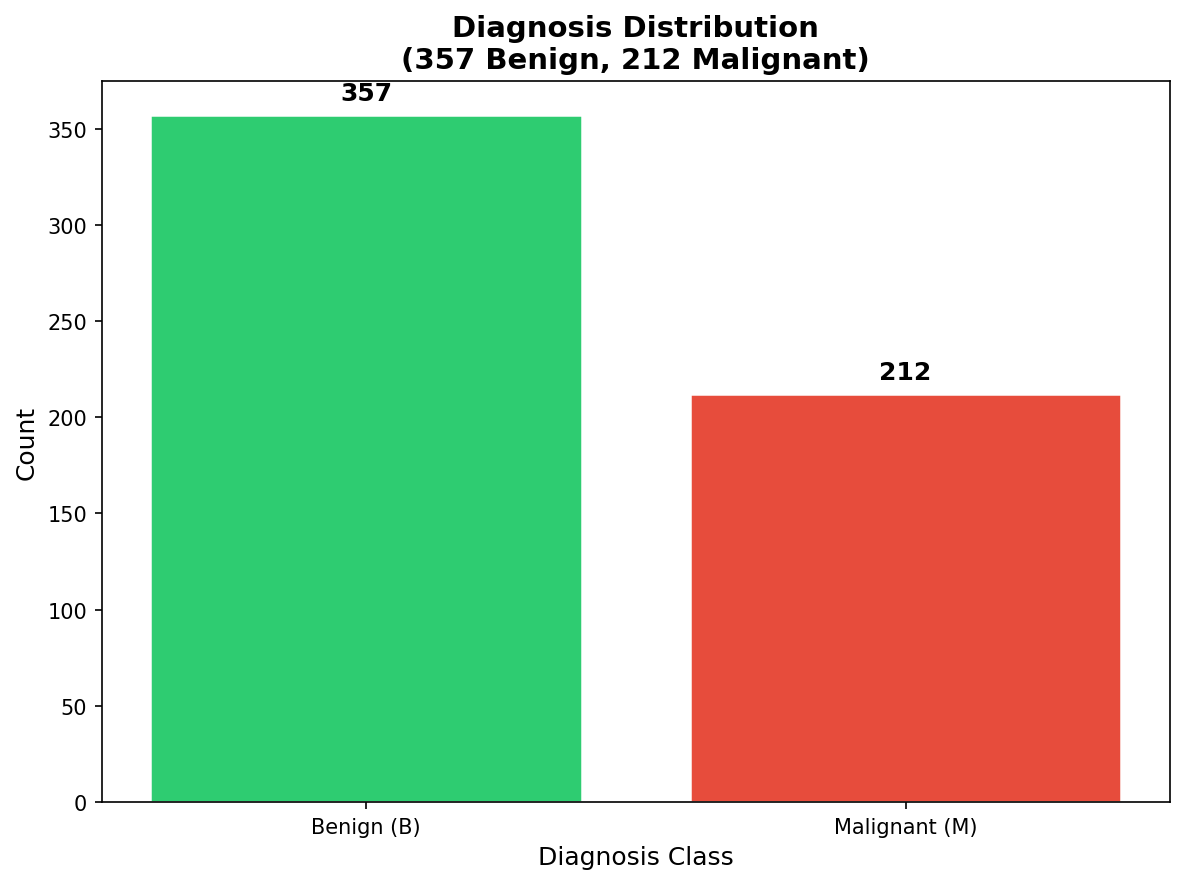

In [4]:
# ── Figure 3: Diagnosis Distribution ──
plt.figure(figsize=(8, 6))
counts = df['diagnosis'].value_counts()
bars = plt.bar(['Benign (B)', 'Malignant (M)'], counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 8, str(val),
             ha='center', fontweight='bold', fontsize=12)
plt.title('Diagnosis Distribution\n(357 Benign, 212 Malignant)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.savefig('fig3_diagnosis_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

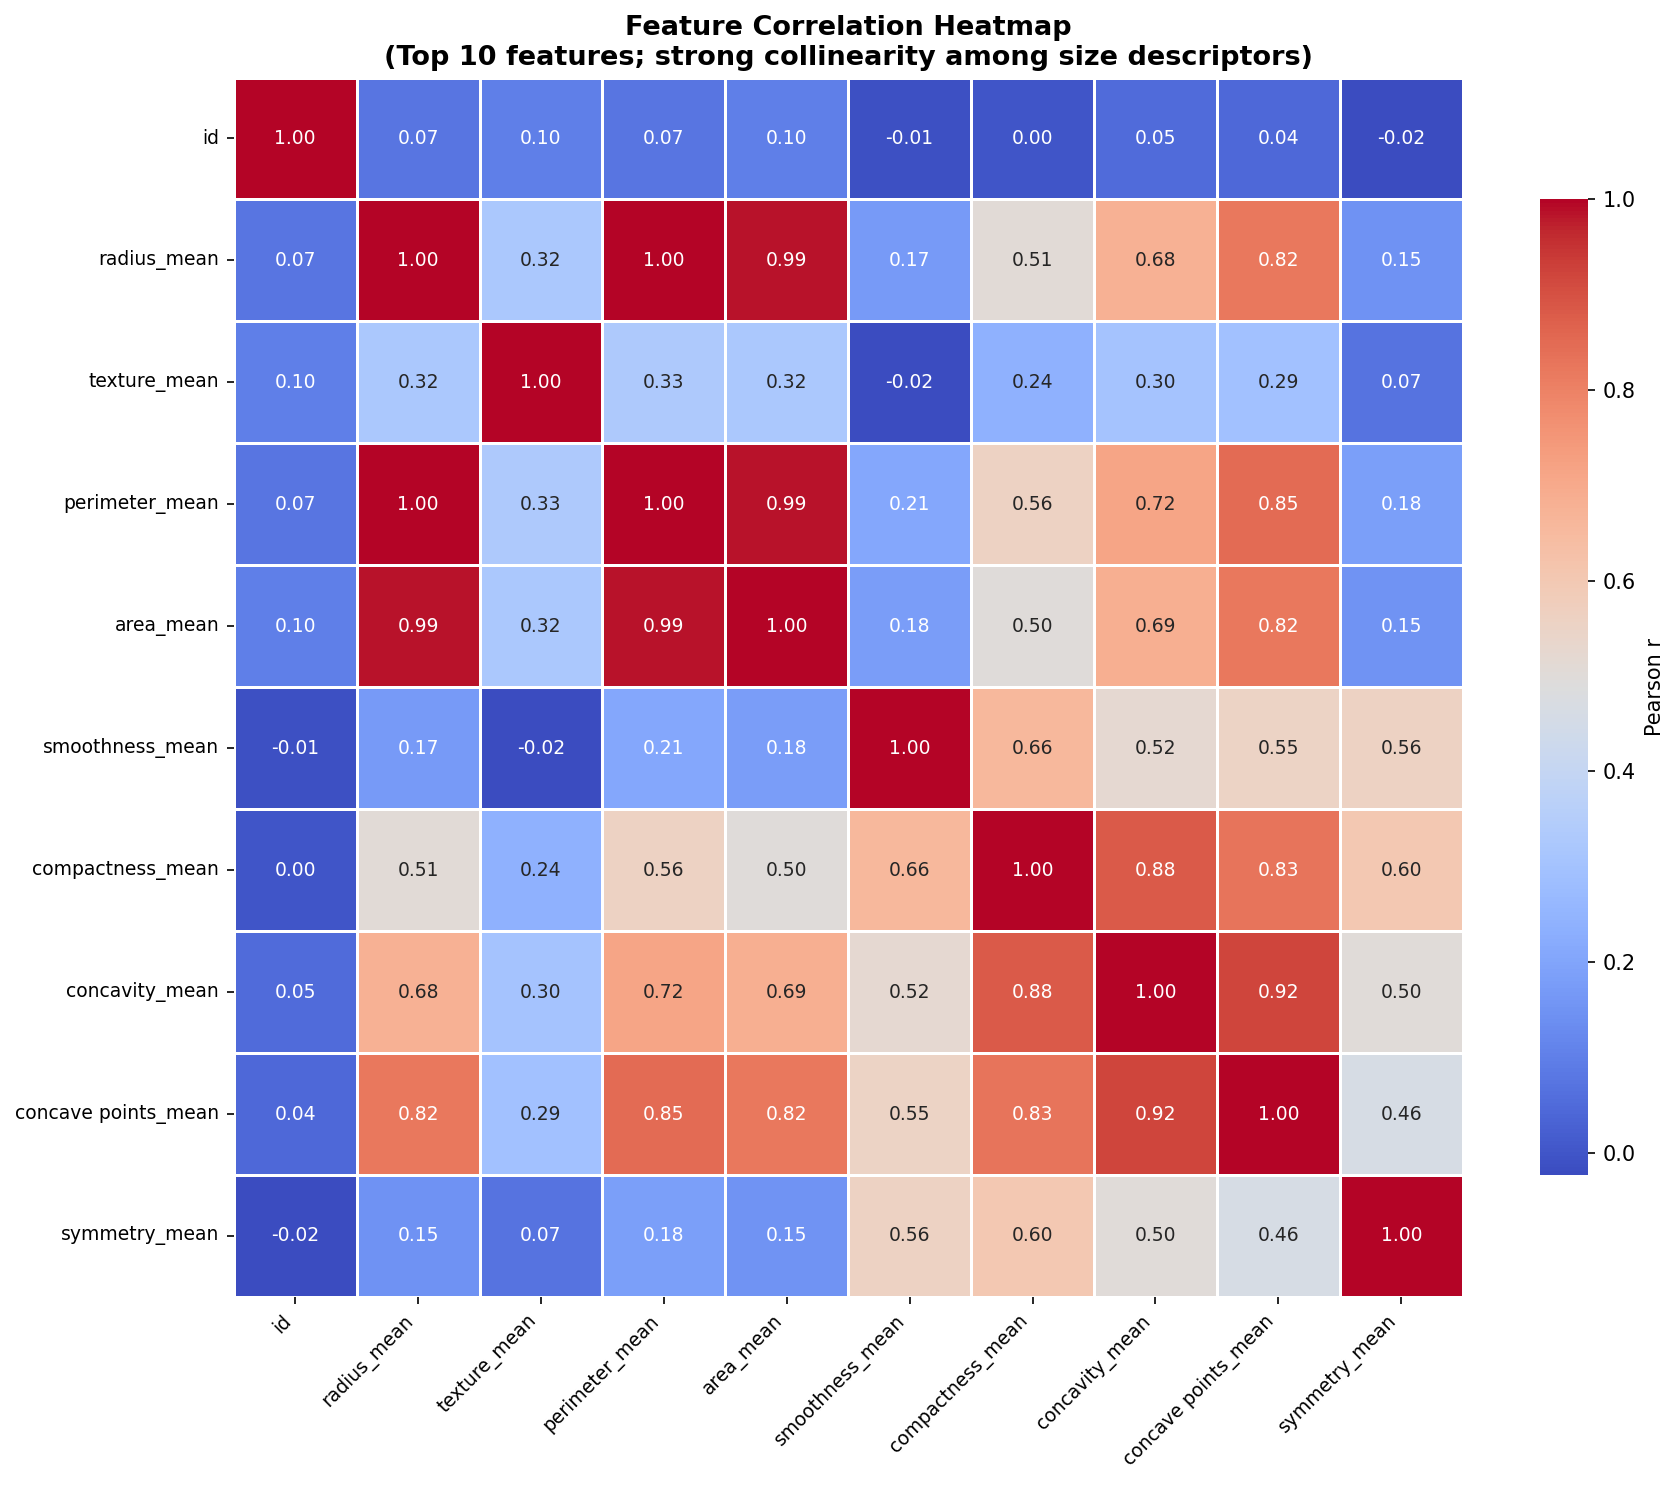

In [5]:
# ── Figure 4: Feature Correlation Heatmap ──
# FIX: use 'mean' in c (sklearn names use spaces not underscores)
numeric_cols = df.select_dtypes(include=[np.number]).columns[:10].tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Heatmap\n(Top 10 features; strong collinearity among size descriptors)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

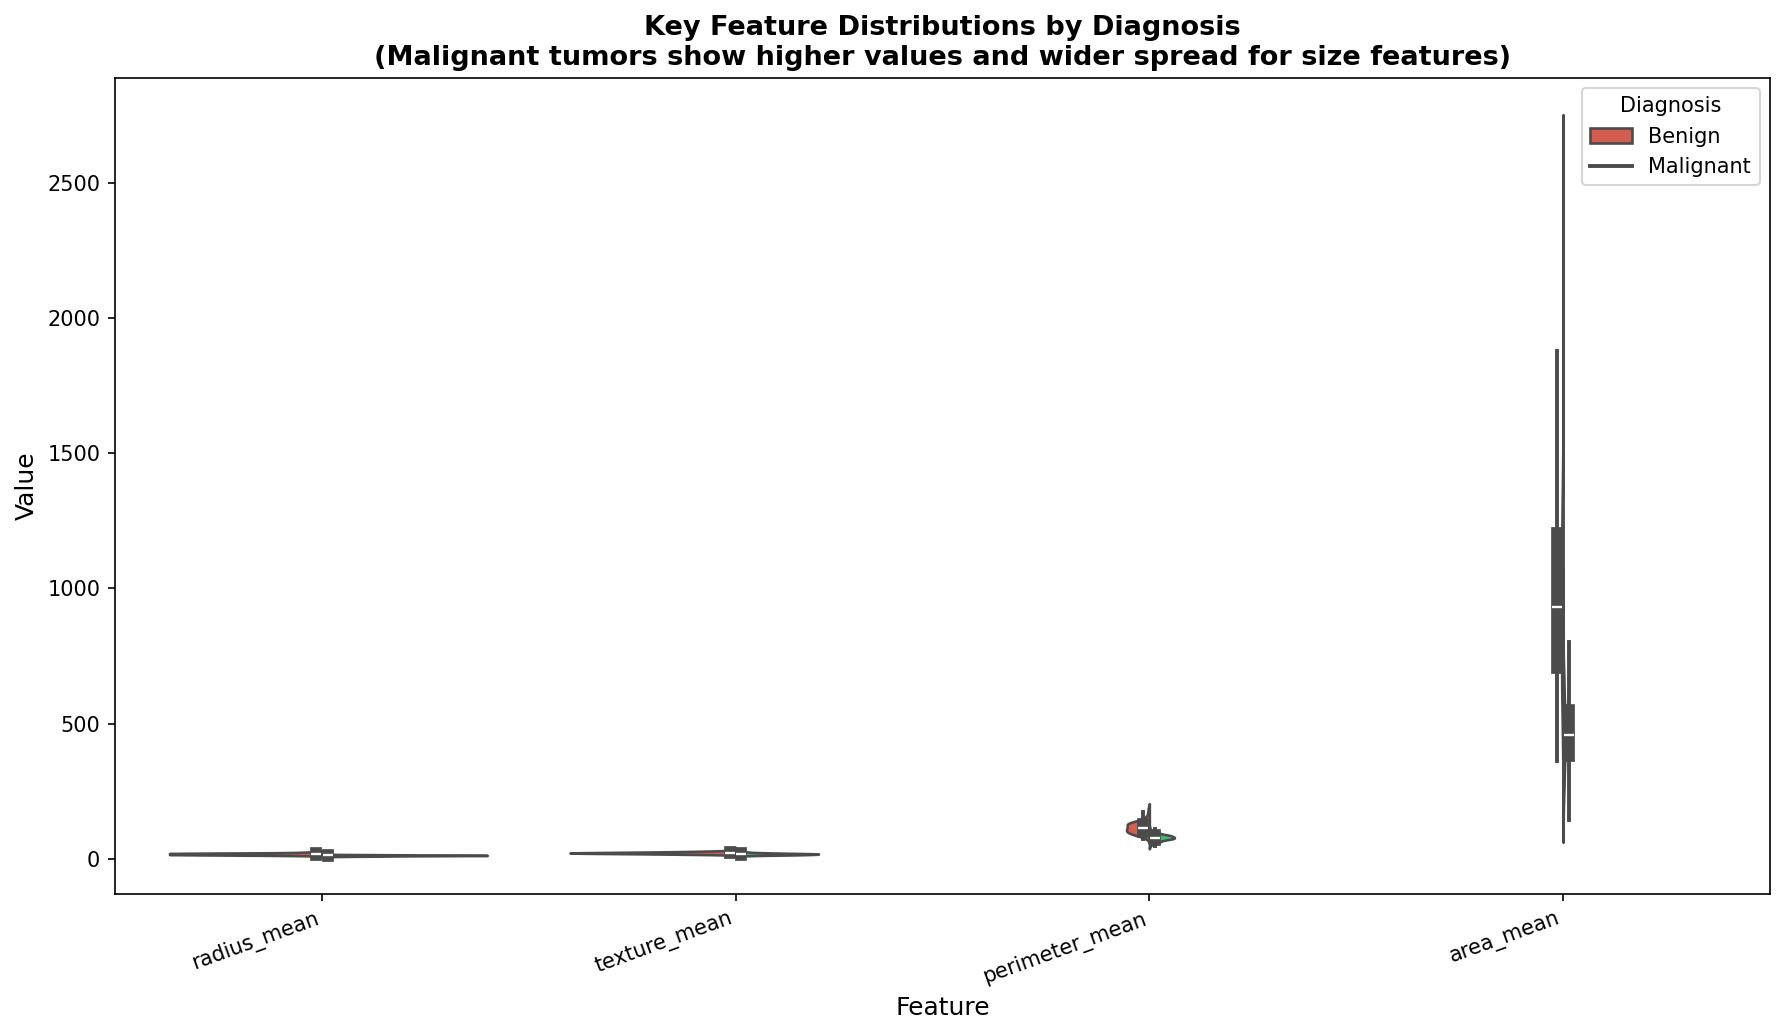

In [6]:
# ── Figure 5: Feature Distributions by Diagnosis ──
key_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']
df_melted = pd.melt(df, id_vars=['diagnosis'], value_vars=key_features)

plt.figure(figsize=(12, 7))
sns.violinplot(data=df_melted, x='variable', y='value', hue='diagnosis',
               split=True, palette={'B': '#2ecc71', 'M': '#e74c3c'})
plt.title('Key Feature Distributions by Diagnosis\n'
          '(Malignant tumors show higher values and wider spread for size features)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(title='Diagnosis', labels=['Benign', 'Malignant'], fontsize=10)
plt.xticks(rotation=20, ha='right', fontsize=10)
plt.tight_layout()
plt.savefig('fig5_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

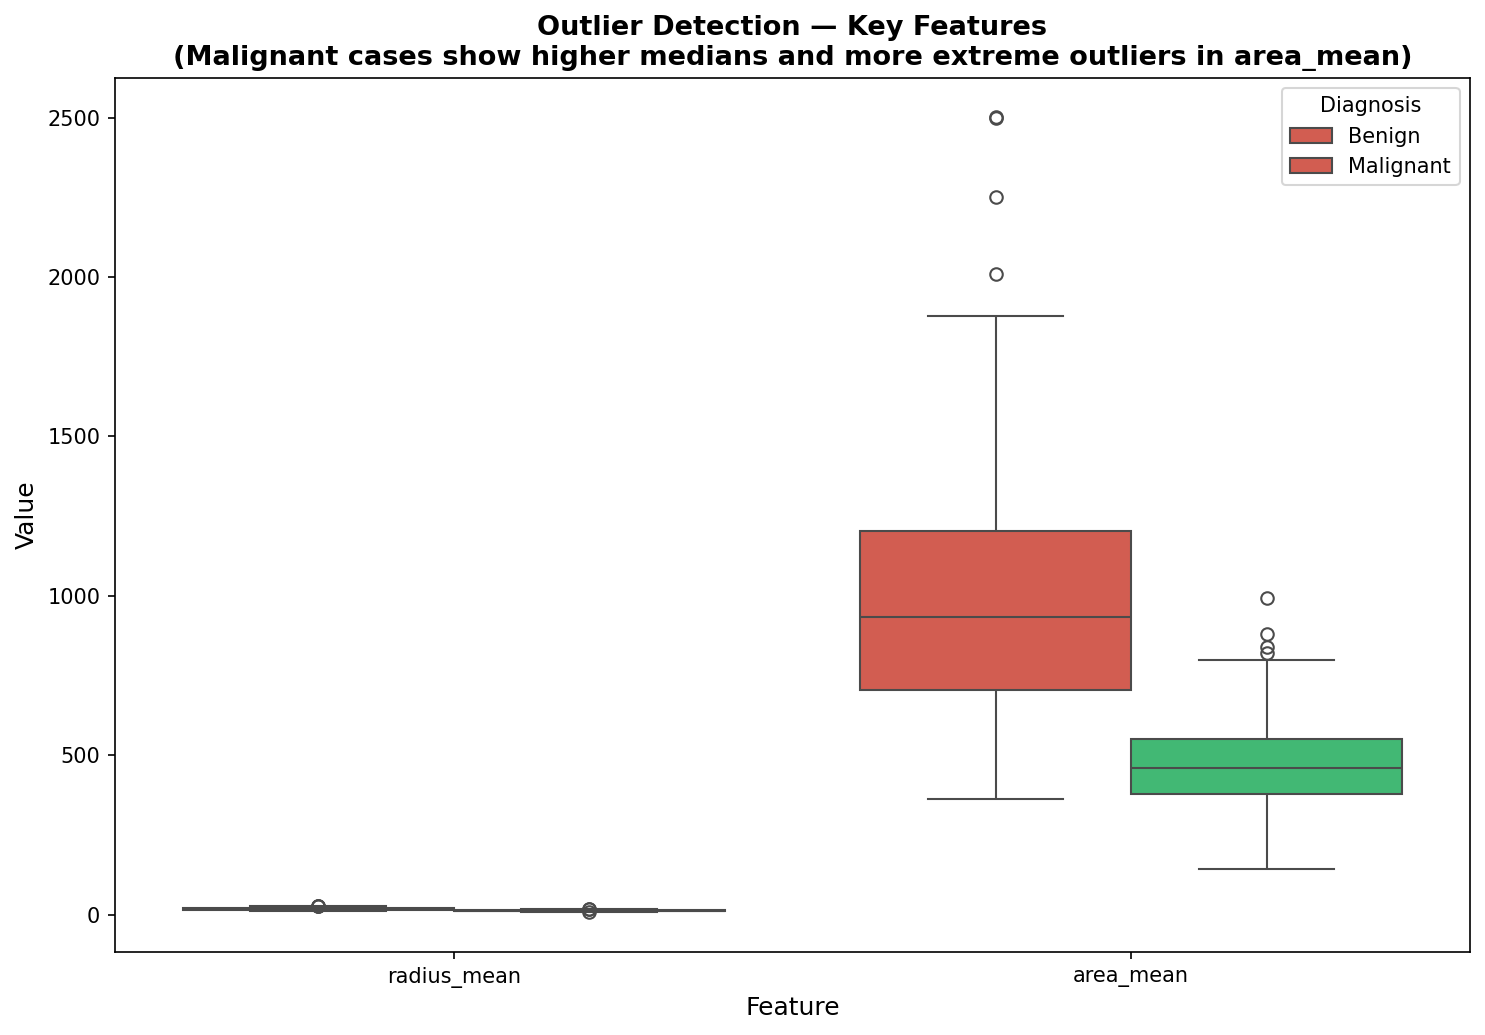

In [7]:
# ── Figure 6: Outlier Detection ──
df_box = df[['diagnosis', 'radius_mean', 'area_mean']].copy()
df_box_melted = pd.melt(df_box, id_vars=['diagnosis'], var_name='feature', value_name='value')

plt.figure(figsize=(10, 7))
sns.boxplot(data=df_box_melted, x='feature', y='value', hue='diagnosis',
            palette={'B': '#2ecc71', 'M': '#e74c3c'})
plt.title('Outlier Detection — Key Features\n'
          '(Malignant cases show higher medians and more extreme outliers in area_mean)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(title='Diagnosis', labels=['Benign', 'Malignant'], fontsize=10)
plt.tight_layout()
plt.savefig('fig6_outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing — Leak-Free Pipeline
**All preprocessing fitted exclusively on training set.**  
Order: Split → Feature Engineering → Scale.

In [8]:
df_clean = df.copy()

# 1. Drop non-informative columns
cols_to_drop = [c for c in ['id', 'Unnamed: 32'] if c in df_clean.columns]
df_clean.drop(columns=cols_to_drop, inplace=True)

# 2. Encode target (B=0, M=1)
le = LabelEncoder()
df_clean['diagnosis'] = le.fit_transform(df_clean['diagnosis'])

X_raw = df_clean.drop('diagnosis', axis=1)
y     = df_clean['diagnosis']

# 3. Stratified train/test split — BEFORE any feature engineering or scaling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f"Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")

Train: (455, 30)  |  Test: (114, 30)
Train class balance: {0: 285, 1: 170}
Test  class balance: {0: 72, 1: 42}


In [9]:
# 4. Feature engineering — formula applied to train, then replicated on test (no fit)
def engineer_features(df_in):
    df_out = df_in.copy()
    df_out['radius_area_ratio']        = df_out['radius_mean'] / (df_out['area_mean'] + 1e-8)
    df_out['perimeter_area_ratio']     = df_out['perimeter_mean'] / (df_out['area_mean'] + 1e-8)
    df_out['concavity_points_product'] = df_out['concavity_mean'] * df_out['concave points_mean']
    return df_out

X_train_eng = engineer_features(X_train_raw)
X_test_eng  = engineer_features(X_test_raw)

feature_names = X_train_eng.columns.tolist()
print(f"Features after engineering: {len(feature_names)}")
print("New features:", [f for f in feature_names if f not in X_raw.columns])

Features after engineering: 33
New features: ['radius_area_ratio', 'perimeter_area_ratio', 'concavity_points_product']


In [10]:
# 5. Scale — scaler fitted on training set only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_eng)
X_test_scaled  = scaler.transform(X_test_eng)
print("Scaling complete (fitted on train only). ✓")

Scaling complete (fitted on train only). ✓


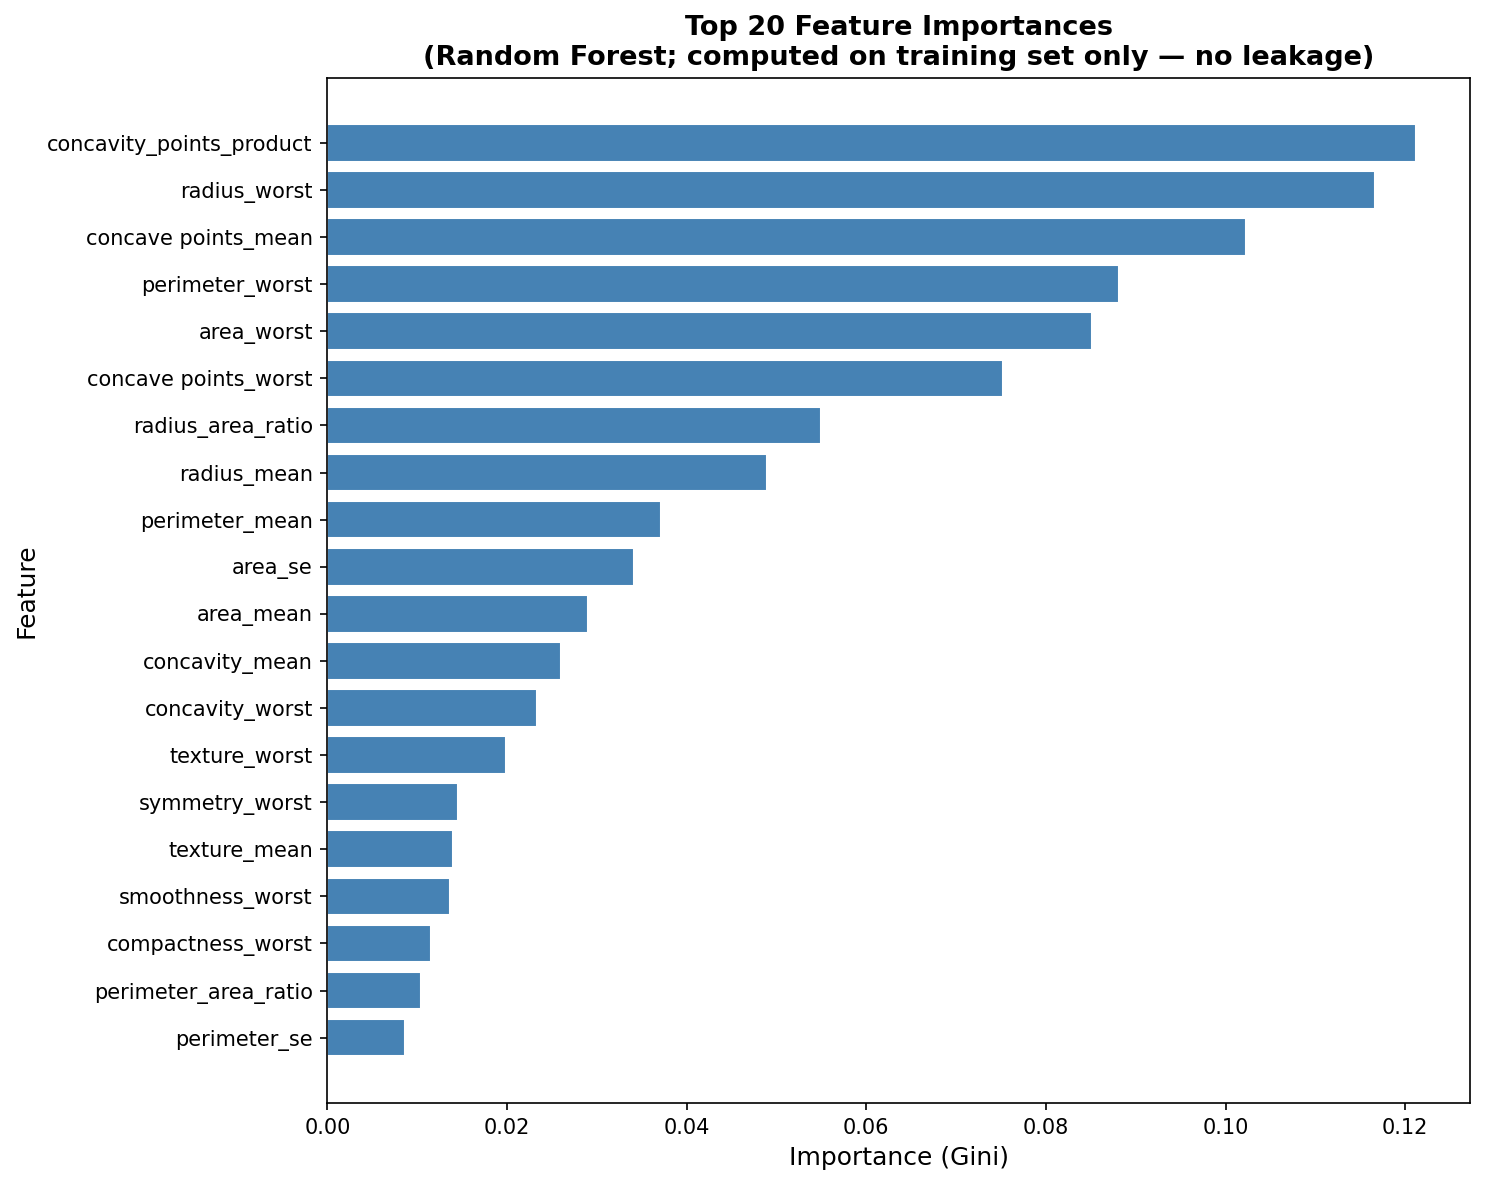

In [11]:
# ── Figure 7: Feature Importance (training set only) ──
rf_for_eda = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_for_eda.fit(X_train_scaled, y_train)

fi_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_for_eda.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
         color='steelblue', edgecolor='white')
plt.xlabel('Importance (Gini)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 20 Feature Importances\n(Random Forest; computed on training set only — no leakage)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Model Training — 12 Classifiers with 5-Fold CV

In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=SEED),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'KNN':                  KNeighborsClassifier(n_neighbors=5),
    'SVM':                  SVC(probability=True, random_state=SEED),
    'Naive Bayes':          GaussianNB(),
    'Decision Tree':        DecisionTreeClassifier(random_state=SEED),
    'MLP':                  MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                          max_iter=500, random_state=SEED,
                                          early_stopping=True),
}
if XGBOOST_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(
        use_label_encoder=False, eval_metric='logloss',
        random_state=SEED, n_jobs=-1, verbosity=0)
if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1)
if CATBOOST_AVAILABLE:
    models['CatBoost'] = CatBoostClassifier(iterations=200, random_seed=SEED, verbose=0)

results = {}
print(f"{'Model':<22} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>8} {'CV Mean':>9} {'CV Std':>8}")
print("-"*85)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    cv_scores = cross_val_score(model, X_train_scaled, y_train,
                                cv=skf, scoring='accuracy', n_jobs=-1)
    results[name] = {
        'model':     model,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'y_pred':    y_pred,
        'y_prob':    y_prob,
        'cv_mean':   cv_scores.mean(),
        'cv_std':    cv_scores.std(),
        'cv_scores': cv_scores,
        'train_time': time.time() - t0,
    }
    r = results[name]
    print(f"{name:<22} {r['accuracy']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} "
          f"{r['f1']:>7.4f} {r['roc_auc']:>8.4f} {r['cv_mean']:>9.4f} {r['cv_std']:>8.4f}")

Model                      Acc    Prec  Recall      F1      AUC   CV Mean   CV Std
-------------------------------------------------------------------------------------
Logistic Regression     0.9737  0.9756  0.9524  0.9639   0.9964    0.9758   0.0146
Random Forest           0.9649  1.0000  0.9048  0.9500   0.9940    0.9604   0.0226
Gradient Boosting       0.9737  1.0000  0.9286  0.9630   0.9921    0.9714   0.0112
Extra Trees             0.9737  1.0000  0.9286  0.9630   0.9983    0.9604   0.0283
KNN                     0.9561  0.9744  0.9048  0.9383   0.9828    0.9736   0.0192
SVM                     0.9737  0.9756  0.9524  0.9639   0.9950    0.9714   0.0054
Naive Bayes             0.9386  0.9730  0.8571  0.9114   0.9934    0.9451   0.0241
Decision Tree           0.9123  0.9211  0.8333  0.8750   0.8958    0.9275   0.0215
MLP                     0.9649  0.9750  0.9286  0.9512   0.9957    0.9407   0.0204
XGBoost                 0.9649  1.0000  0.9048  0.9500   0.9911    0.9692   0.0146


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM                0.9649  1.0000  0.9048  0.9500   0.9881    0.9670   0.0098
CatBoost                0.9737  1.0000  0.9286  0.9630   0.9980    0.9692   0.0108


In [13]:
# ── TabNet (needs float32 arrays) ────────────────────────────────────────────
if TABNET_AVAILABLE:
    print("Training TabNet...")
    tabnet = TabNetClassifier(
        n_d=32, n_a=32, n_steps=5, gamma=1.5,
        n_independent=2, n_shared=2,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-3),
        scheduler_params={"step_size": 50, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax', seed=SEED, verbose=0
    )
    tabnet.fit(
        X_train_scaled.astype(np.float32), y_train.values.astype(int),
        eval_set=[(X_test_scaled.astype(np.float32), y_test.values.astype(int))],
        patience=20, max_epochs=200, eval_metric=['auc']
    )
    y_pred_tab  = tabnet.predict(X_test_scaled.astype(np.float32))
    y_prob_tab  = tabnet.predict_proba(X_test_scaled.astype(np.float32))[:, 1]
    cv_tab = cross_val_score(tabnet, X_train_scaled.astype(np.float32),
                             y_train.values.astype(int), cv=skf, scoring='accuracy')
    results['TabNet'] = {
        'model':     tabnet,
        'accuracy':  accuracy_score(y_test, y_pred_tab),
        'precision': precision_score(y_test, y_pred_tab),
        'recall':    recall_score(y_test, y_pred_tab),
        'f1':        f1_score(y_test, y_pred_tab),
        'roc_auc':   roc_auc_score(y_test, y_prob_tab),
        'y_pred':    y_pred_tab,
        'y_prob':    y_prob_tab,
        'cv_mean':   cv_tab.mean(),
        'cv_std':    cv_tab.std(),
        'cv_scores': cv_tab,
        'train_time': 0,
    }
    r = results['TabNet']
    print(f"{'TabNet':<22} {r['accuracy']:>7.4f} {r['precision']:>7.4f} {r['recall']:>7.4f} "
          f"{r['f1']:>7.4f} {r['roc_auc']:>8.4f} {r['cv_mean']:>9.4f} {r['cv_std']:>8.4f}")
else:
    print("TabNet not available — skipping.")

Training TabNet...

Early stopping occurred at epoch 20 with best_epoch = 0 and best_val_0_auc = 0.5587
TabNet                  0.3421  0.3514  0.9286  0.5098   0.5587    0.3758   0.0128


In [14]:
# Table 2: Full results sorted by ROC-AUC
res_df = pd.DataFrame([{
    'Model':     k,
    'Accuracy':  f"{v['accuracy']:.4f}",
    'Precision': f"{v['precision']:.4f}",
    'Recall':    f"{v['recall']:.4f}",
    'F1-Score':  f"{v['f1']:.4f}",
    'ROC-AUC':   f"{v['roc_auc']:.4f}",
    'CV Mean':   f"{v['cv_mean']:.4f}",
    'CV Std':    f"{v['cv_std']:.4f}",
} for k, v in results.items()])
res_df = res_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("Table 2: Individual Model Performance (12 models)")
print(res_df.to_string(index=False))

Table 2: Individual Model Performance (12 models)
              Model Accuracy Precision Recall F1-Score ROC-AUC CV Mean CV Std
        Extra Trees   0.9737    1.0000 0.9286   0.9630  0.9983  0.9604 0.0283
           CatBoost   0.9737    1.0000 0.9286   0.9630  0.9980  0.9692 0.0108
Logistic Regression   0.9737    0.9756 0.9524   0.9639  0.9964  0.9758 0.0146
                MLP   0.9649    0.9750 0.9286   0.9512  0.9957  0.9407 0.0204
                SVM   0.9737    0.9756 0.9524   0.9639  0.9950  0.9714 0.0054
      Random Forest   0.9649    1.0000 0.9048   0.9500  0.9940  0.9604 0.0226
        Naive Bayes   0.9386    0.9730 0.8571   0.9114  0.9934  0.9451 0.0241
  Gradient Boosting   0.9737    1.0000 0.9286   0.9630  0.9921  0.9714 0.0112
            XGBoost   0.9649    1.0000 0.9048   0.9500  0.9911  0.9692 0.0146
           LightGBM   0.9649    1.0000 0.9048   0.9500  0.9881  0.9670 0.0098
                KNN   0.9561    0.9744 0.9048   0.9383  0.9828  0.9736 0.0192
      Decision

## 6. Ensemble Model — Calibrated Soft Voting
Tree models (RF, LightGBM, CatBoost) wrapped with Platt scaling before soft-voting.

In [15]:
lr_base  = LogisticRegression(max_iter=2000, random_state=SEED)
rf_base  = CalibratedClassifierCV(
               RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
               method='sigmoid', cv=5)

base_estimators = [('lr', lr_base), ('rf', rf_base)]

if LIGHTGBM_AVAILABLE:
    lgb_base = CalibratedClassifierCV(
                   lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1),
                   method='sigmoid', cv=5)
    lgb_base.fit(X_train_scaled, y_train)
    base_estimators.append(('lgb', lgb_base))

if CATBOOST_AVAILABLE:
    cat_base = CalibratedClassifierCV(
                   CatBoostClassifier(iterations=200, random_seed=SEED, verbose=0),
                   method='sigmoid', cv=5)
    cat_base.fit(X_train_scaled, y_train)
    base_estimators.append(('cat', cat_base))

lr_base.fit(X_train_scaled, y_train)
rf_base.fit(X_train_scaled, y_train)

voting_clf = VotingClassifier(estimators=base_estimators, voting='soft')
voting_clf.fit(X_train_scaled, y_train)

y_pred_ensemble = voting_clf.predict(X_test_scaled)
y_prob_ensemble = voting_clf.predict_proba(X_test_scaled)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ensemble).ravel()
ens_metrics = {
    'Accuracy':    accuracy_score(y_test, y_pred_ensemble),
    'Precision':   precision_score(y_test, y_pred_ensemble),
    'Recall':      recall_score(y_test, y_pred_ensemble),
    'F1-Score':    f1_score(y_test, y_pred_ensemble),
    'ROC-AUC':     roc_auc_score(y_test, y_prob_ensemble),
    'Specificity': tn / (tn + fp),
    'NPV':         tn / (tn + fn),
    'FPR':         fp / (fp + tn),
    'FNR':         fn / (fn + tp),
    'Brier Score': brier_score_loss(y_test, y_prob_ensemble),
}
print("Ensemble (Calibrated Soft Voting) — Full Performance:")
print("-"*50)
for k, v in ens_metrics.items():
    print(f"  {k:<14}: {v:.4f}")

Ensemble (Calibrated Soft Voting) — Full Performance:
--------------------------------------------------
  Accuracy      : 0.9737
  Precision     : 1.0000
  Recall        : 0.9286
  F1-Score      : 0.9630
  ROC-AUC       : 0.9967
  Specificity   : 1.0000
  NPV           : 0.9600
  FPR           : 0.0000
  FNR           : 0.0714
  Brier Score   : 0.0204


## 7. Comprehensive Statistical Tests
Friedman → McNemar (pairwise) → Bonferroni/FDR correction → DeLong AUC → Wilcoxon

In [16]:
print("="*70)
print("COMPREHENSIVE STATISTICAL TESTS")
print("="*70)

# ── 1. Friedman Test ─────────────────────────────────────────────────────────
print("\n── 1. Friedman Test (global: are any models significantly different?) ──")
score_matrix = np.array([v['cv_scores'] for v in results.values()])  # (n_models, 5)
friedman_stat, friedman_p = stats.friedmanchisquare(*score_matrix.T)
print(f"  Friedman statistic : {friedman_stat:.4f}")
print(f"  p-value            : {friedman_p:.6f}")
if friedman_p < 0.05:
    print("  → Significant differences exist among models (p < 0.05)")
else:
    print("  → No significant global difference detected")

# ── 2. Pairwise McNemar (Ensemble vs each model) ─────────────────────────────
print("\n── 2. Pairwise McNemar Tests (Ensemble vs each individual model) ──")
model_names = list(results.keys())
p_values, comparisons = [], []

ens_correct = (y_pred_ensemble == y_test.values)
for name in model_names:
    other_correct = (results[name]['y_pred'] == y_test.values)
    b = np.sum(~other_correct & ens_correct)
    c = np.sum(other_correct & ~ens_correct)
    table = np.array([[np.sum(ens_correct & other_correct), c],
                      [b, np.sum(~ens_correct & ~other_correct)]])
    res_mc = mcnemar_test(table, exact=True)
    p_values.append(res_mc.pvalue)
    comparisons.append(name)
    print(f"  Ensemble vs {name:22s} | b={b}, c={c} | p={res_mc.pvalue:.4f}")

# ── 3. Multiple comparison correction ────────────────────────────────────────
print("\n── 3. Multiple Comparison Correction ──")
reject_bonf, p_bonf, _, _ = multipletests(p_values, method='bonferroni')
reject_fdr,  p_fdr,  _, _ = multipletests(p_values, method='fdr_bh')

correction_df = pd.DataFrame({
    'Comparison':   [f'Ensemble vs {n}' for n in comparisons],
    'Raw p':        [f"{p:.4f}" for p in p_values],
    'Bonferroni p': [f"{p:.4f}" for p in p_bonf],
    'Bonf sig':     ['Yes' if r else 'No' for r in reject_bonf],
    'FDR (BH) p':   [f"{p:.4f}" for p in p_fdr],
    'FDR sig':      ['Yes' if r else 'No' for r in reject_fdr],
})
print(correction_df.to_string(index=False))

COMPREHENSIVE STATISTICAL TESTS

── 1. Friedman Test (global: are any models significantly different?) ──
  Friedman statistic : 25.8410
  p-value            : 0.000034
  → Significant differences exist among models (p < 0.05)

── 2. Pairwise McNemar Tests (Ensemble vs each individual model) ──
  Ensemble vs Logistic Regression    | b=2, c=2 | p=1.0000
  Ensemble vs Random Forest          | b=2, c=1 | p=1.0000
  Ensemble vs Gradient Boosting      | b=0, c=0 | p=1.0000
  Ensemble vs Extra Trees            | b=0, c=0 | p=1.0000
  Ensemble vs KNN                    | b=2, c=0 | p=0.5000
  Ensemble vs SVM                    | b=2, c=2 | p=1.0000
  Ensemble vs Naive Bayes            | b=4, c=0 | p=0.1250
  Ensemble vs Decision Tree          | b=8, c=1 | p=0.0391
  Ensemble vs MLP                    | b=2, c=1 | p=1.0000
  Ensemble vs XGBoost                | b=1, c=0 | p=1.0000
  Ensemble vs LightGBM               | b=1, c=0 | p=1.0000
  Ensemble vs CatBoost               | b=0, c=0 | p=1.0

In [17]:
# ── 4. Bootstrap DeLong AUC test ────────────────────────────────────────────
print("\n── 4. Bootstrap DeLong Test (AUC: Ensemble vs Logistic Regression) ──")

def delong_bootstrap(y_true, proba_a, proba_b, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    auc_a = roc_auc_score(y_true, proba_a)
    auc_b = roc_auc_score(y_true, proba_b)
    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(np.array(y_true)[idx])) < 2:
            continue
        da = roc_auc_score(np.array(y_true)[idx], proba_a[idx])
        db = roc_auc_score(np.array(y_true)[idx], proba_b[idx])
        deltas.append(da - db)
    deltas = np.array(deltas)
    p = 2 * min(np.mean(deltas >= 0), np.mean(deltas <= 0))
    ci_lo, ci_hi = np.percentile(deltas, [2.5, 97.5])
    return auc_a, auc_b, auc_a - auc_b, p, ci_lo, ci_hi

lr_prob = results['Logistic Regression']['y_prob']
auc_ens, auc_lr, delta, p_auc, ci_lo, ci_hi = delong_bootstrap(
    y_test.values, y_prob_ensemble, lr_prob
)
print(f"  Ensemble AUC  : {auc_ens:.4f}")
print(f"  LR AUC        : {auc_lr:.4f}")
print(f"  ΔAUC          : {delta:+.4f}")
print(f"  95% CI (ΔAUC) : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  p-value       : {p_auc:.4f}")
if p_auc < 0.05:
    print("  → Statistically significant AUC improvement (p < 0.05)")
else:
    print("  → AUC improvement not statistically significant on this test set size.")
    print("     External validation on a larger cohort is recommended.")

# ── 5. Wilcoxon Signed-Rank (CV scores: LR vs each other model) ──────────────
print("\n── 5. Wilcoxon Signed-Rank Test (CV Accuracy: LR vs each other model) ──")
lr_cv = results['Logistic Regression']['cv_scores']
for name in model_names:
    if name == 'Logistic Regression':
        continue
    other_cv = results[name]['cv_scores']
    try:
        w_stat, w_p = stats.wilcoxon(lr_cv, other_cv, alternative='two-sided')
        sig = '✓ sig' if w_p < 0.05 else '✗ not sig'
        print(f"  LR vs {name:22s} | W={w_stat:.1f} | p={w_p:.4f} | {sig}")
    except Exception as e:
        print(f"  LR vs {name:22s} | Could not compute: {e}")


── 4. Bootstrap DeLong Test (AUC: Ensemble vs Logistic Regression) ──
  Ensemble AUC  : 0.9967
  LR AUC        : 0.9964
  ΔAUC          : +0.0003
  95% CI (ΔAUC) : [-0.0023, 0.0032]
  p-value       : 0.9600
  → AUC improvement not statistically significant on this test set size.
     External validation on a larger cohort is recommended.

── 5. Wilcoxon Signed-Rank Test (CV Accuracy: LR vs each other model) ──
  LR vs Random Forest          | W=2.5 | p=0.5000 | ✗ not sig
  LR vs Gradient Boosting      | W=4.5 | p=1.0000 | ✗ not sig
  LR vs Extra Trees            | W=4.0 | p=0.4375 | ✗ not sig
  LR vs KNN                    | W=7.0 | p=1.0000 | ✗ not sig
  LR vs SVM                    | W=4.0 | p=1.0000 | ✗ not sig
  LR vs Naive Bayes            | W=2.0 | p=0.1875 | ✗ not sig
  LR vs Decision Tree          | W=0.0 | p=0.0625 | ✗ not sig
  LR vs MLP                    | W=1.0 | p=0.1250 | ✗ not sig
  LR vs XGBoost                | W=7.0 | p=1.0000 | ✗ not sig
  LR vs LightGBM           

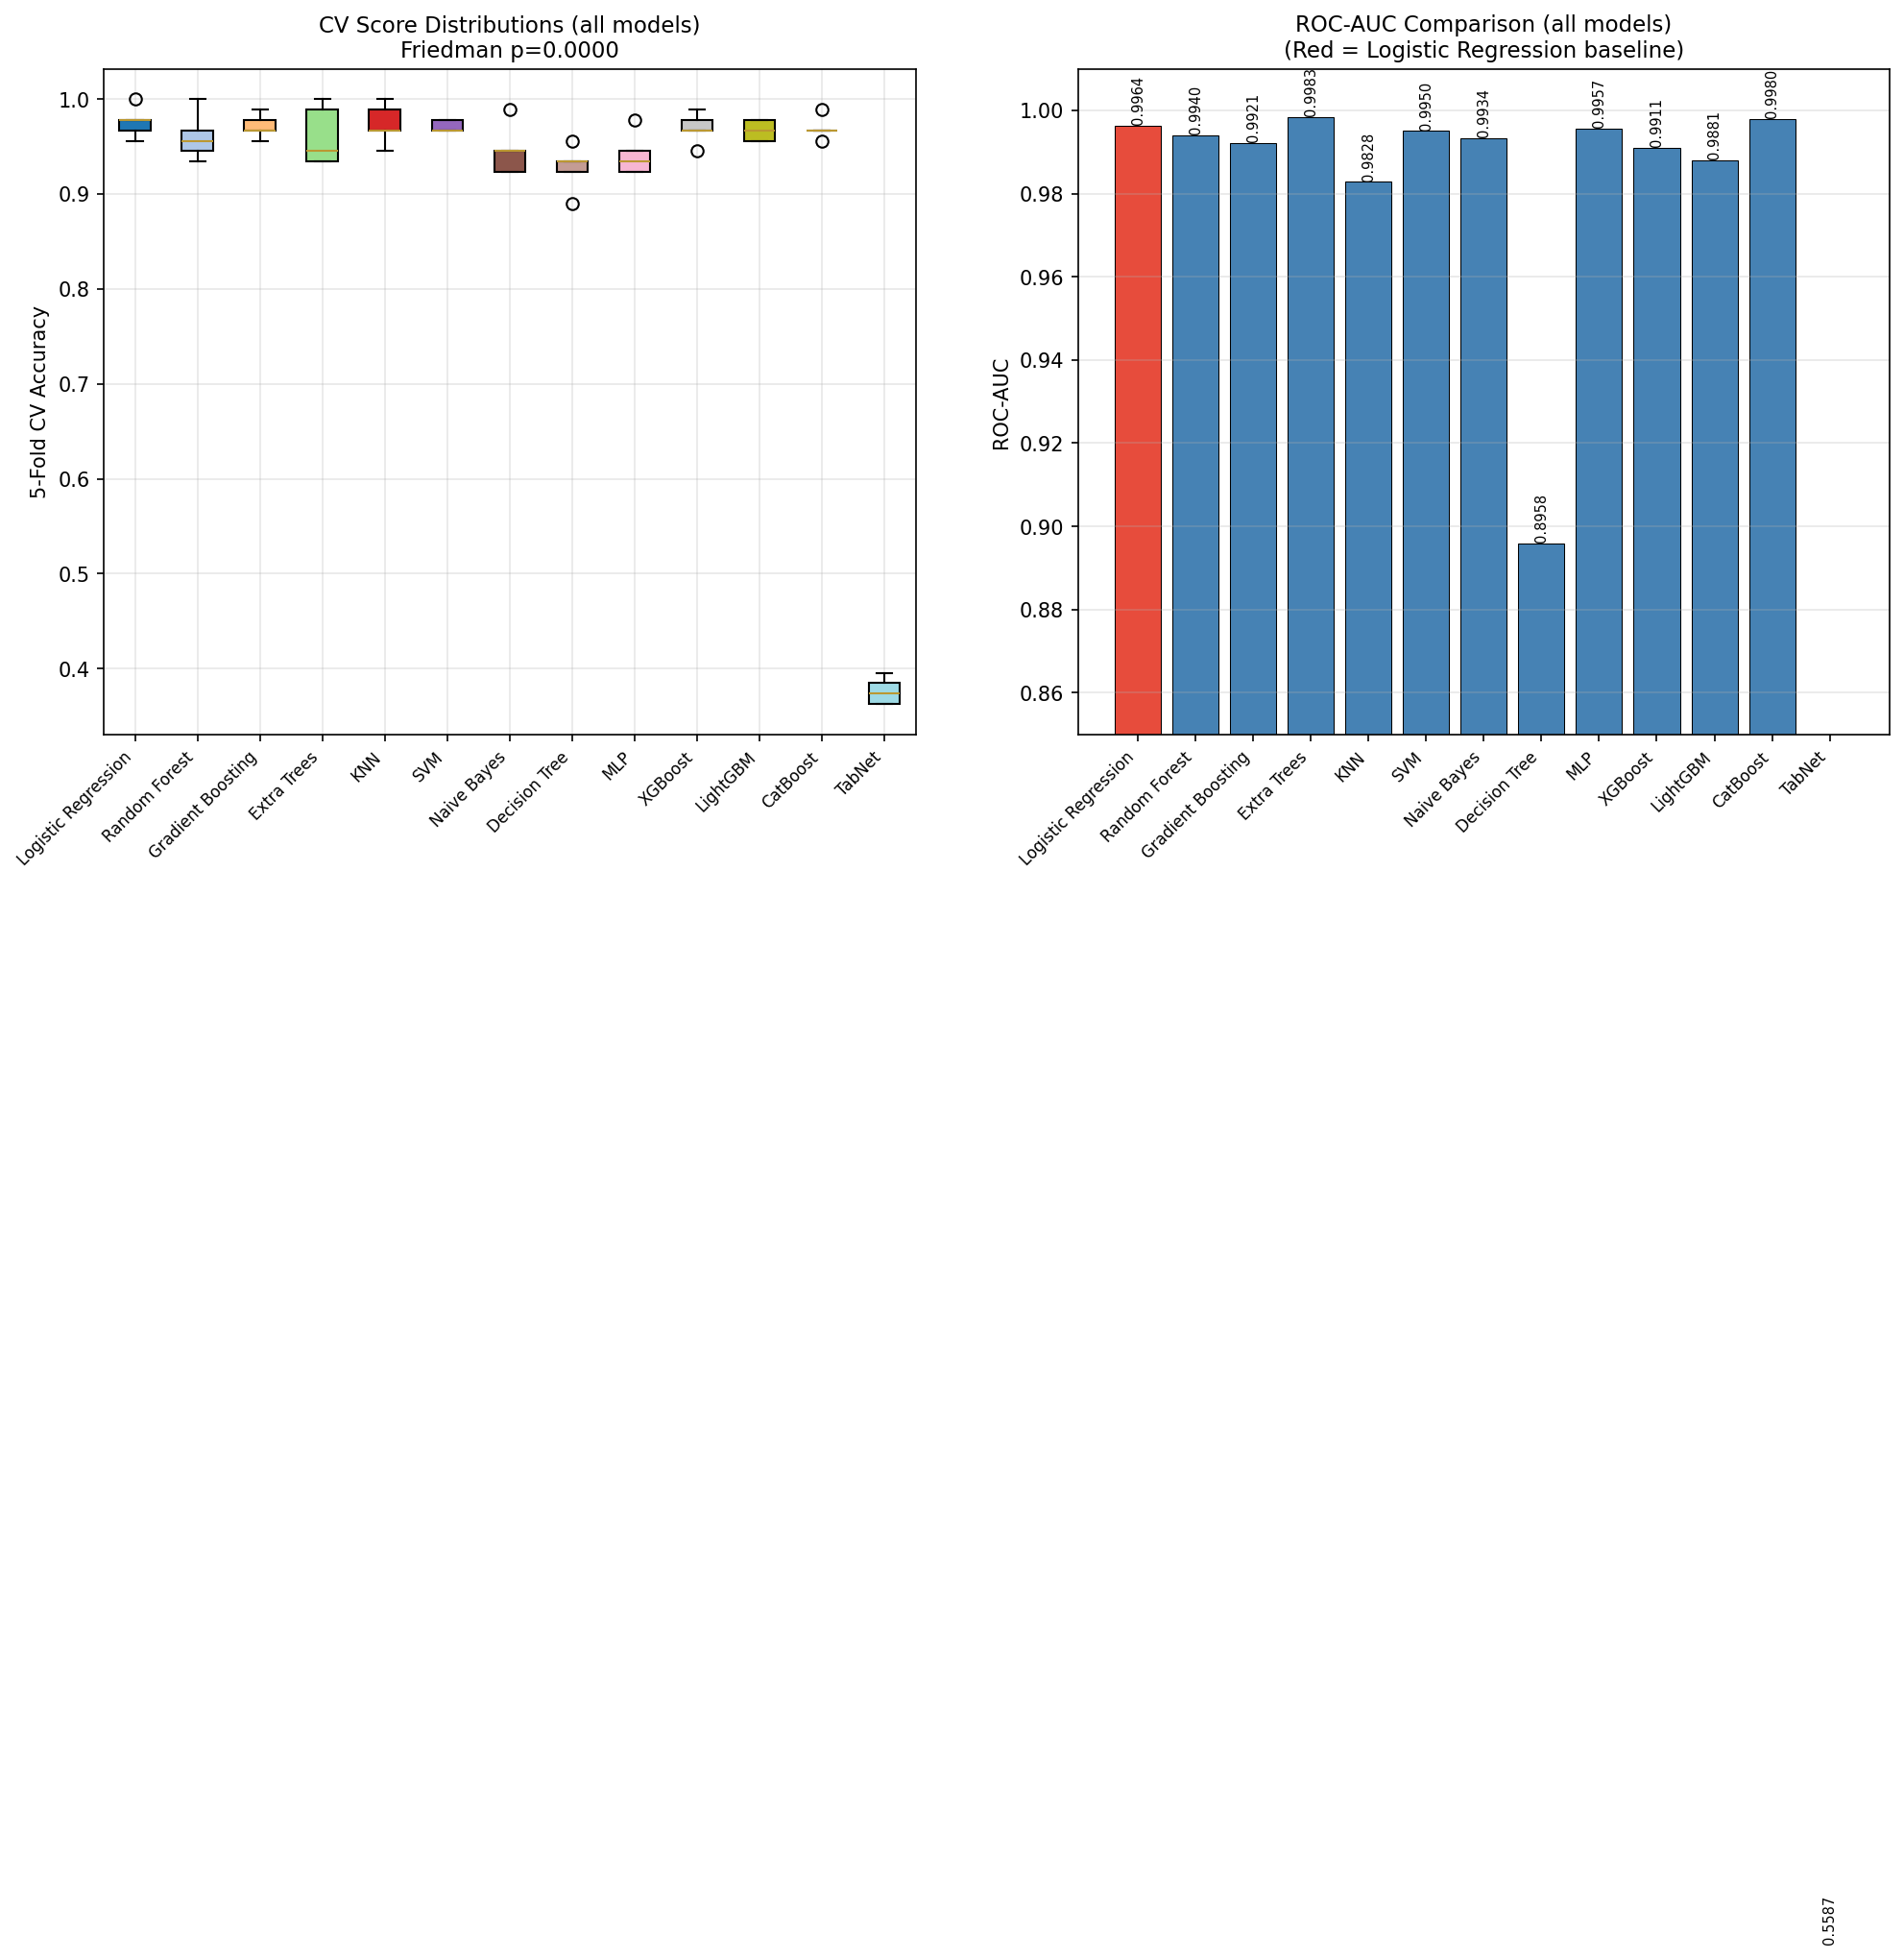

Saved fig_statistical_comparison.png


In [18]:
# ── Statistical summary visualization ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CV score box plots
cv_data  = [results[n]['cv_scores'] for n in model_names]
ax = axes[0]
bp = ax.boxplot(cv_data, patch_artist=True, notch=False)
colors = plt.cm.tab20(np.linspace(0, 1, len(model_names)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.set_xticks(range(1, len(model_names)+1))
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=10)
ax.set_title(f'CV Score Distributions (all models)\nFriedman p={friedman_p:.4f}', fontsize=11)
ax.grid(True, alpha=0.3)

# AUC bar chart
ax2 = axes[1]
auc_vals    = [results[n]['roc_auc'] for n in model_names]
bar_colors  = ['#e74c3c' if n == 'Logistic Regression' else 'steelblue' for n in model_names]
bars = ax2.bar(model_names, auc_vals, color=bar_colors, edgecolor='black', linewidth=0.5)
ax2.set_xticks(range(len(model_names)))
ax2.set_xticklabels(model_names, rotation=45, ha='right', fontsize=8)
ax2.set_ylabel('ROC-AUC', fontsize=10)
ax2.set_ylim(0.85, 1.01)
ax2.set_title('ROC-AUC Comparison (all models)\n(Red = Logistic Regression baseline)', fontsize=11)
for bar, val in zip(bars, auc_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', fontsize=7, rotation=90)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_statistical_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved fig_statistical_comparison.png")

## 8. Confusion Matrix & Extended Clinical Metrics

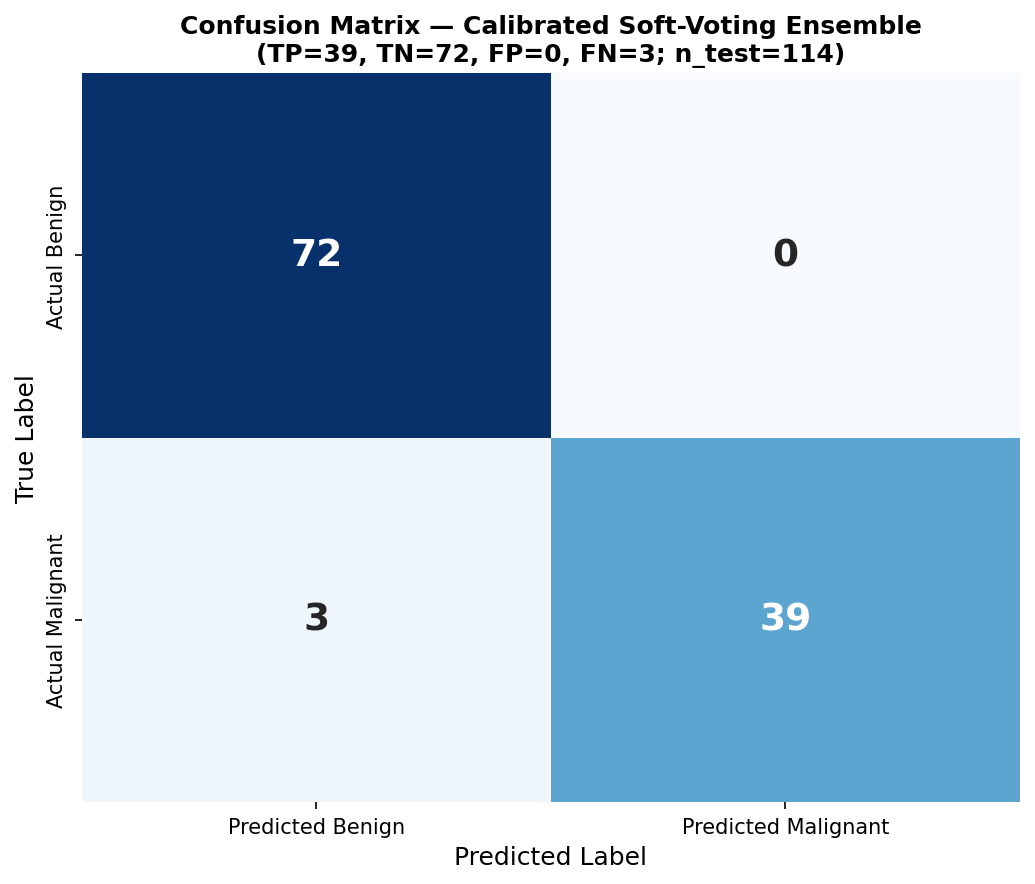


Full Clinical Metrics:
  Sensitivity (TPR) : 0.9286
  Specificity (TNR) : 1.0000
  Precision (PPV)   : 1.0000
  NPV               : 0.9600
  FPR               : 0.0000
  FNR               : 0.0714
  Misclassification : 0.0263


In [19]:
cm = confusion_matrix(y_test, y_pred_ensemble)
tn, fp, fn, tp_val = cm.ravel()

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'],
            annot_kws={'size': 18, 'weight': 'bold'})
plt.title(f'Confusion Matrix — Calibrated Soft-Voting Ensemble\n'
          f'(TP={tp_val}, TN={tn}, FP={fp}, FN={fn}; n_test={len(y_test)})',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('fig9_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFull Clinical Metrics:")
print(f"  Sensitivity (TPR) : {tp_val/(tp_val+fn):.4f}")
print(f"  Specificity (TNR) : {tn/(tn+fp):.4f}")
print(f"  Precision (PPV)   : {tp_val/(tp_val+fp) if (tp_val+fp)>0 else float('nan'):.4f}")
print(f"  NPV               : {tn/(tn+fn):.4f}")
print(f"  FPR               : {fp/(fp+tn):.4f}")
print(f"  FNR               : {fn/(fn+tp_val):.4f}")
print(f"  Misclassification : {(fp+fn)/len(y_test):.4f}")

## 9. XAI — Layer 1: SHAP (Global + Local)

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

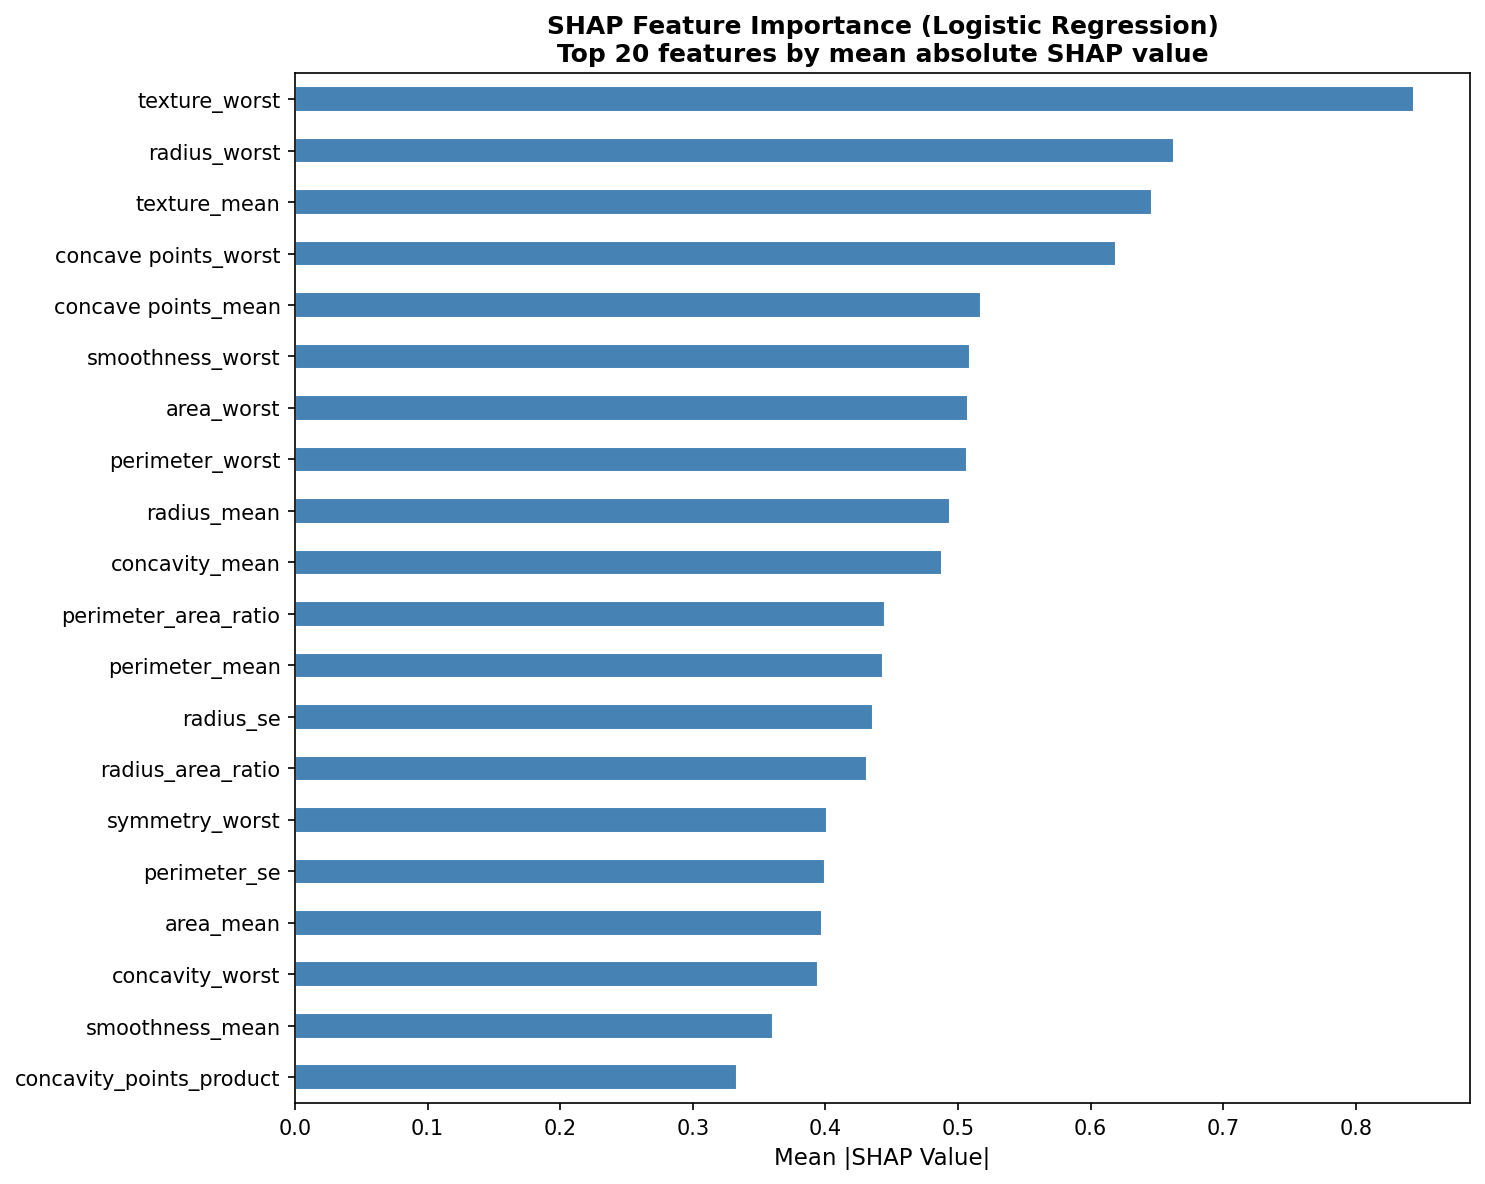

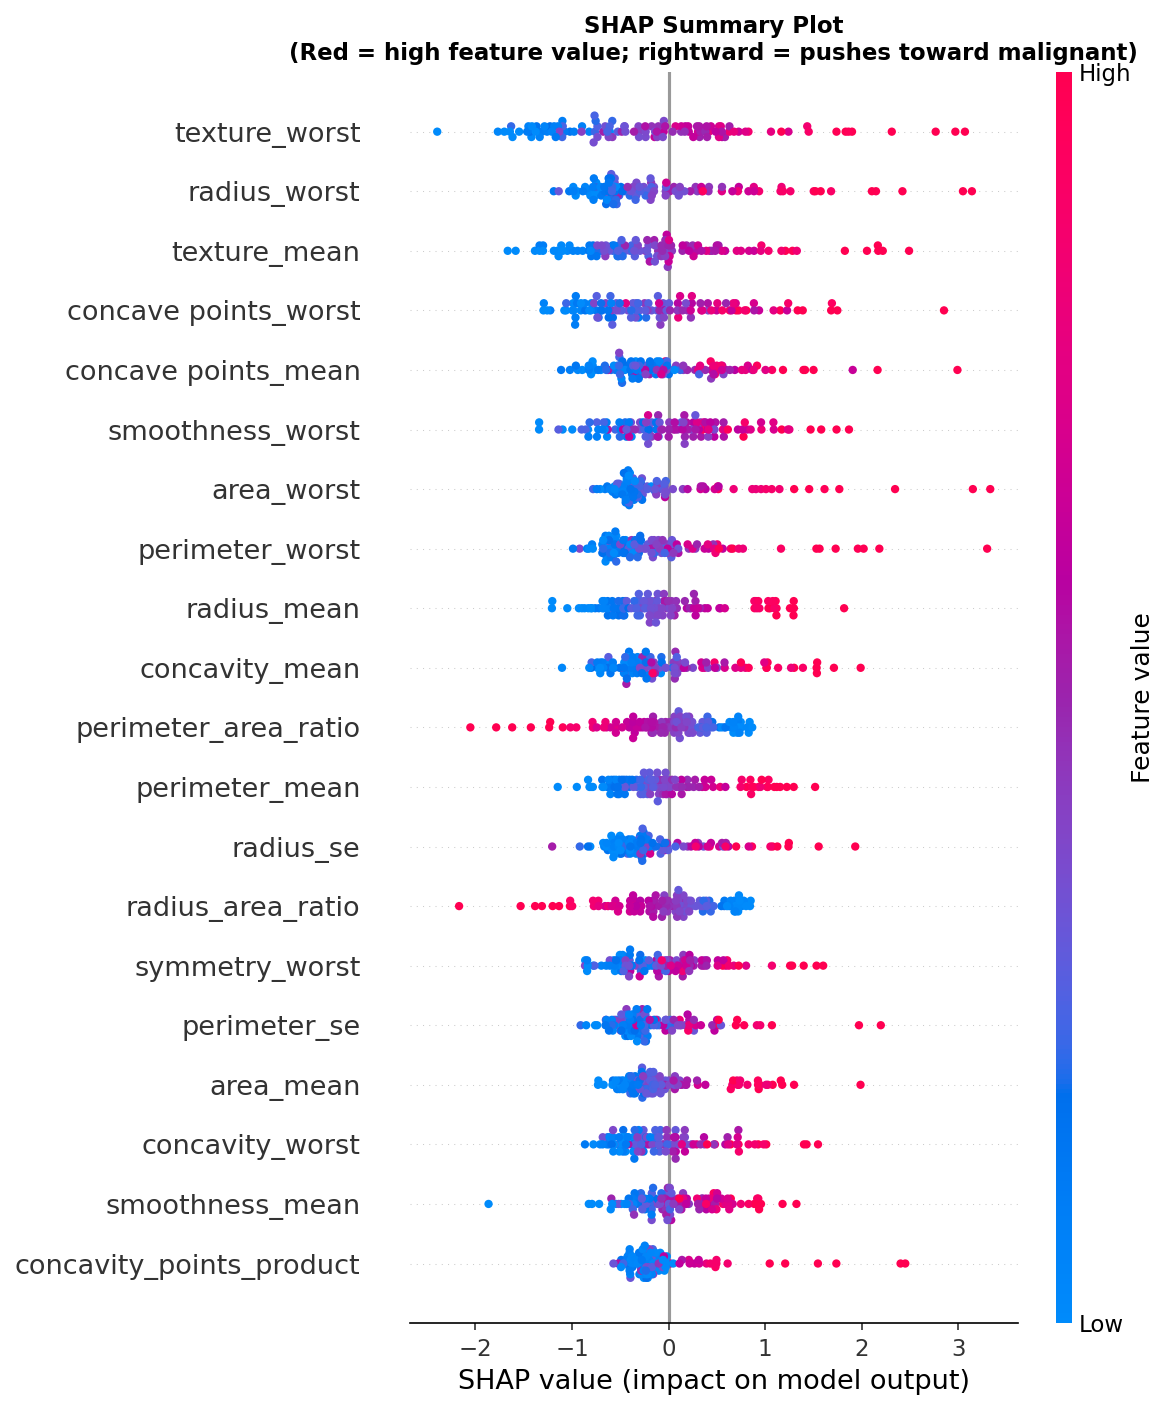

Top 5 features by SHAP: ['texture_worst', 'radius_worst', 'texture_mean', 'concave points_worst', 'concave points_mean']


In [20]:
if SHAP_AVAILABLE:
    lr_fitted    = lr_base
    explainer_lr = shap.LinearExplainer(lr_fitted, X_train_scaled,
                                        feature_perturbation='correlation_dependent')
    shap_values_lr = explainer_lr.shap_values(X_test_scaled)

    shap_df    = pd.DataFrame(np.abs(shap_values_lr), columns=feature_names)
    mean_shap  = shap_df.mean().sort_values(ascending=False)

    # Figure 10a
    plt.figure(figsize=(10, 8))
    mean_shap.head(20).sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
    plt.xlabel('Mean |SHAP Value|', fontsize=11)
    plt.title('SHAP Feature Importance (Logistic Regression)\nTop 20 features by mean absolute SHAP value',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig10a_shap_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Figure 10b
    plt.figure(figsize=(12, 9))
    shap.summary_plot(shap_values_lr, X_test_scaled,
                      feature_names=feature_names, show=False)
    plt.title('SHAP Summary Plot\n(Red = high feature value; rightward = pushes toward malignant)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig10b_shap_summary.png', dpi=300, bbox_inches='tight')
    plt.show()

    top5_shap = mean_shap.head(5).index.tolist()
    print("Top 5 features by SHAP:", top5_shap)
else:
    print("SHAP not available.")
    top5_shap = ['concave points_worst', 'area_worst', 'texture_worst',
                 'concave points_mean', 'radius_worst']

## 10. XAI — Layer 2: Permutation Feature Importance (PFI)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

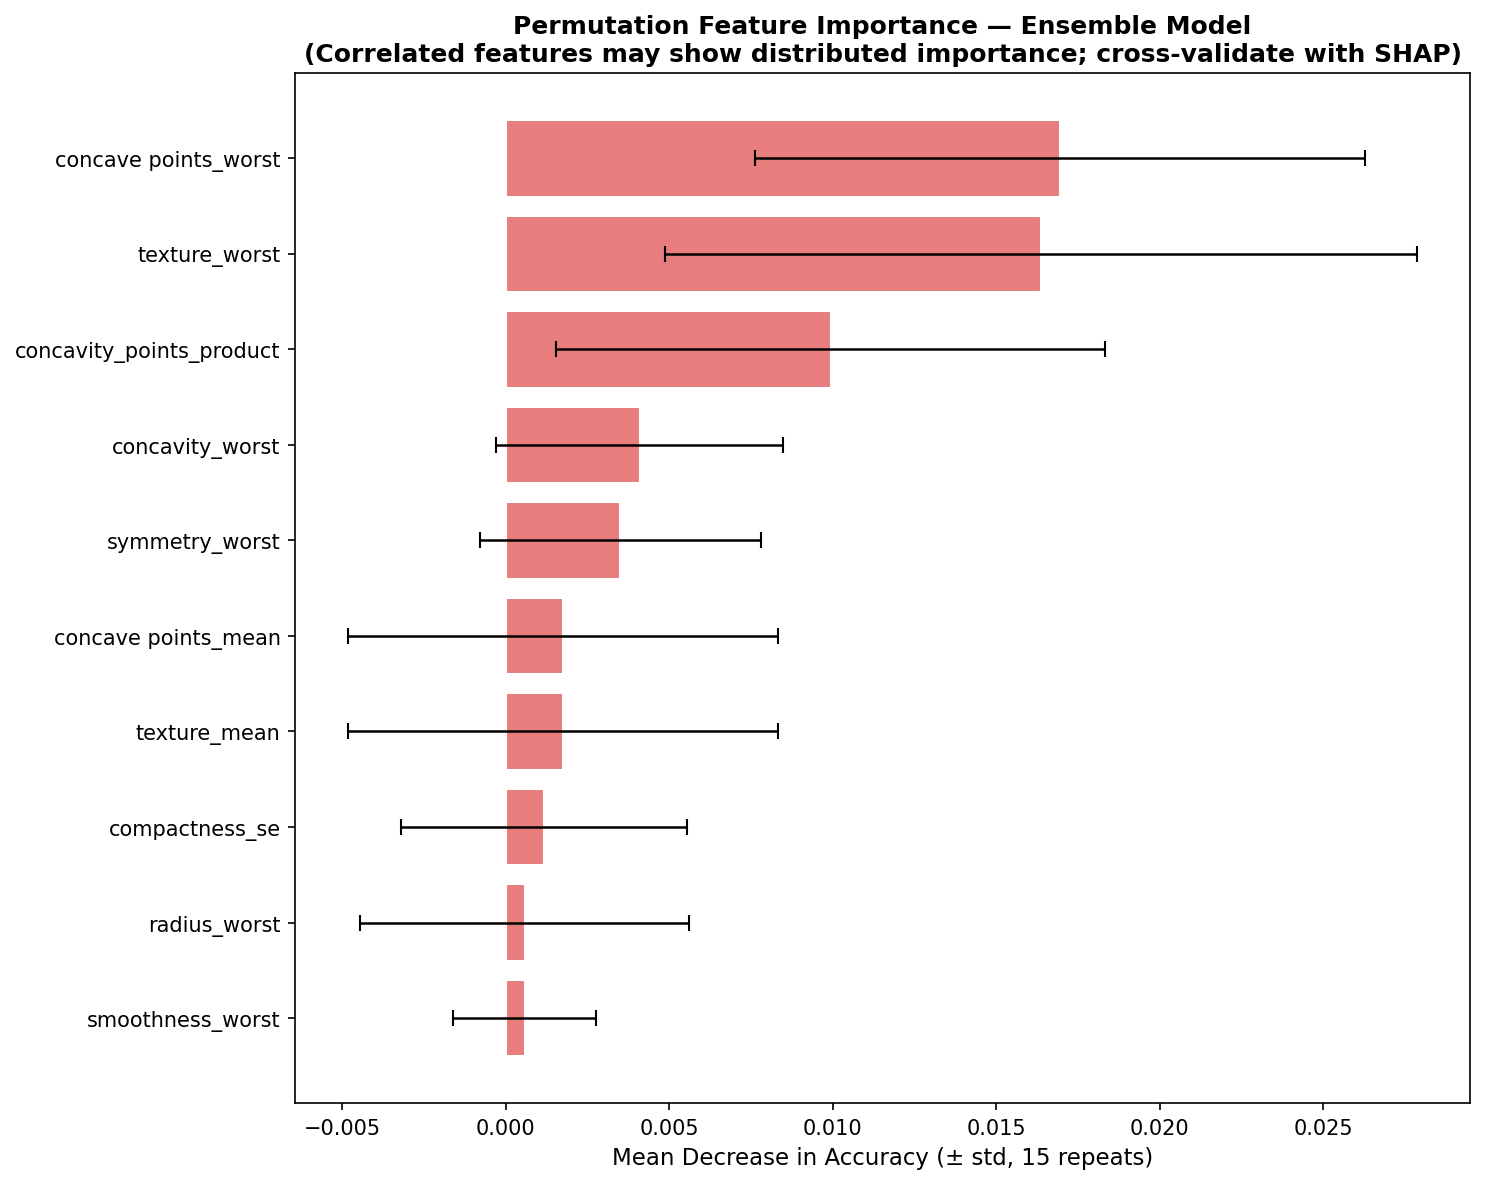

Top 10 PFI features:
                 Feature  Importance      Std
    concave points_worst    0.016959 0.009320
           texture_worst    0.016374 0.011489
concavity_points_product    0.009942 0.008393
         concavity_worst    0.004094 0.004376
          symmetry_worst    0.003509 0.004297
     concave points_mean    0.001754 0.006564
            texture_mean    0.001754 0.006564
          compactness_se    0.001170 0.004376
            radius_worst    0.000585 0.005031
        smoothness_worst    0.000585 0.002188


In [21]:
pfi_result = permutation_importance(
    voting_clf, X_test_scaled, y_test,
    n_repeats=15, random_state=SEED, scoring='accuracy', n_jobs=-1
)
pfi_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': pfi_result.importances_mean,
    'Std':        pfi_result.importances_std,
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
top_pfi = pfi_df.head(10)
plt.barh(top_pfi['Feature'][::-1], top_pfi['Importance'][::-1],
         xerr=top_pfi['Std'][::-1], color='#e87d7d', edgecolor='white',
         capsize=4, error_kw={'linewidth': 1.2})
plt.xlabel('Mean Decrease in Accuracy (± std, 15 repeats)', fontsize=11)
plt.title('Permutation Feature Importance — Ensemble Model\n'
          '(Correlated features may show distributed importance; cross-validate with SHAP)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_pfi.png', dpi=300, bbox_inches='tight')
plt.show()
print("Top 10 PFI features:")
print(pfi_df[['Feature','Importance','Std']].head(10).to_string(index=False))

## 11. XAI — Layer 3: Partial Dependence Plots (PDP)

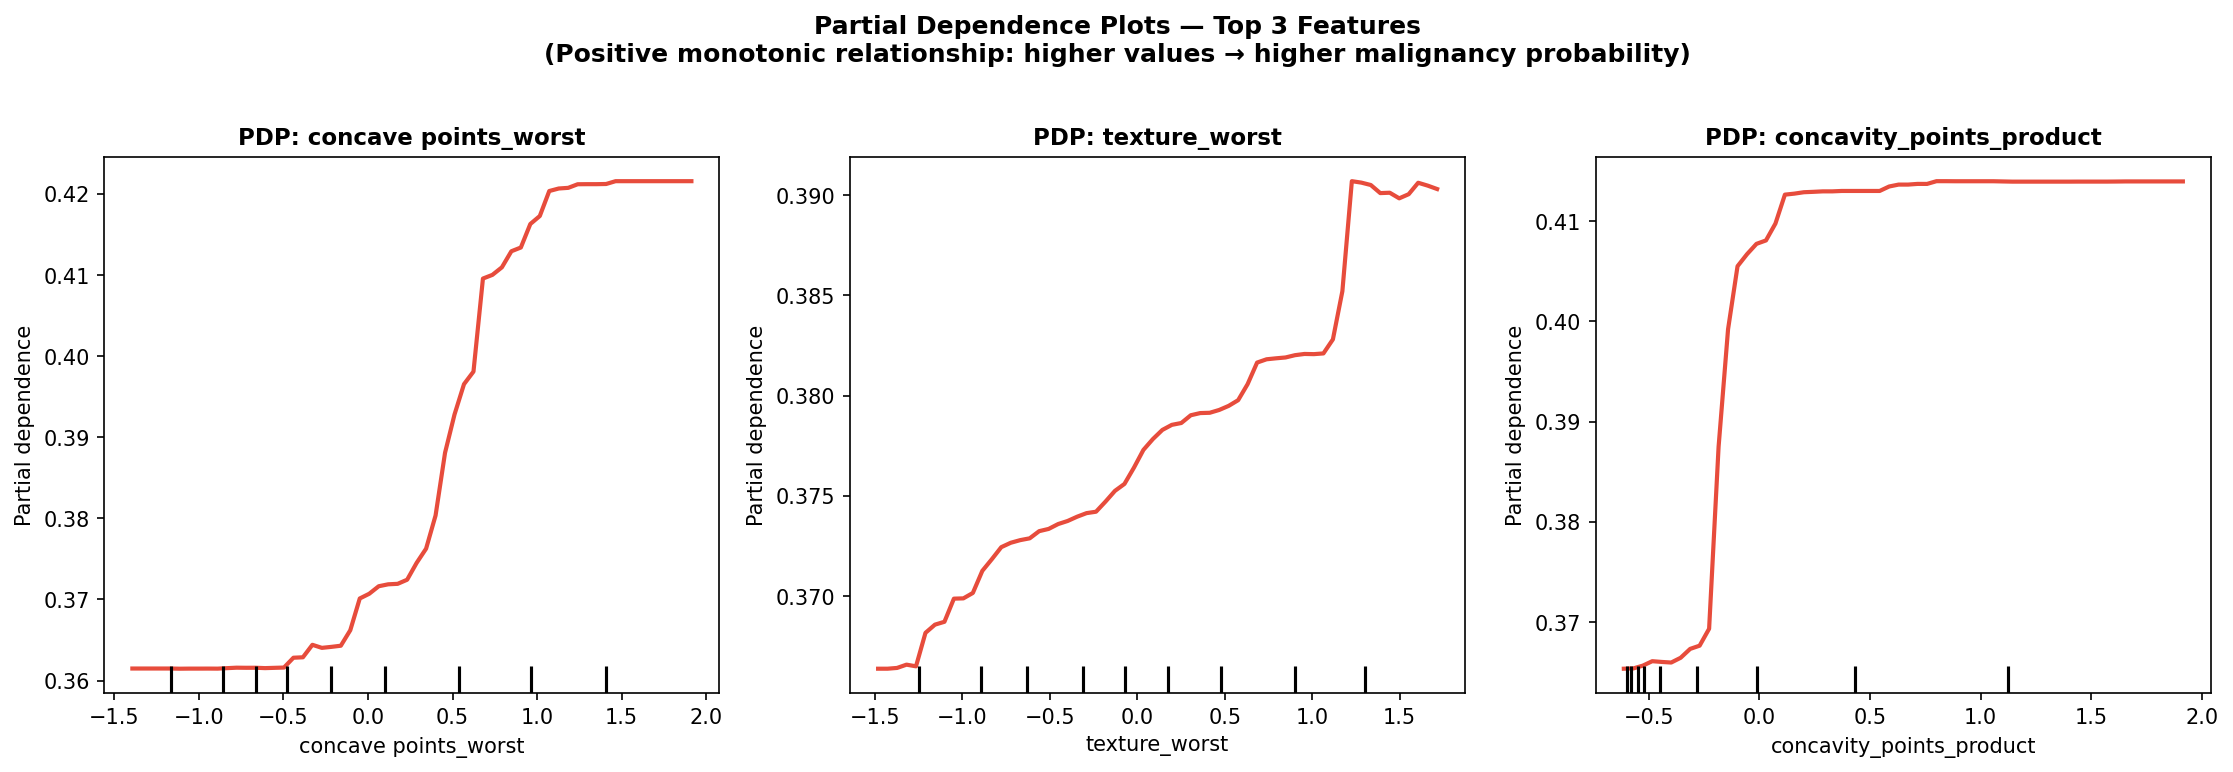

In [22]:
top3_pdp = pfi_df['Feature'].head(3).tolist()
feature_indices = [feature_names.index(f) for f in top3_pdp]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat_idx, feat_name in zip(axes, feature_indices, top3_pdp):
    PartialDependenceDisplay.from_estimator(
        rf_base, X_train_scaled,
        features=[feat_idx],
        feature_names=feature_names,
        ax=ax, grid_resolution=60,
        line_kw={'color': '#e74c3c', 'linewidth': 2}
    )
    ax.set_title(f'PDP: {feat_name}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feat_name, fontsize=10)
    ax.set_ylabel('Partial Dependence\n(P(Malignant))', fontsize=9)

plt.suptitle('Partial Dependence Plots — Top 3 Features\n'
             '(Positive monotonic relationship: higher values → higher malignancy probability)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig12_pdp.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. XAI — Layer 4: ALE Plots (Accumulated Local Effects)
Manual implementation — no alibi/pyALE dependency required.

  radius_mean: ALE zero-crossing at standardised value ≈ -1.04
    → Malignancy risk increases sharply above this threshold.
  perimeter_mean: ALE zero-crossing at standardised value ≈ -0.87
    → Malignancy risk increases sharply above this threshold.


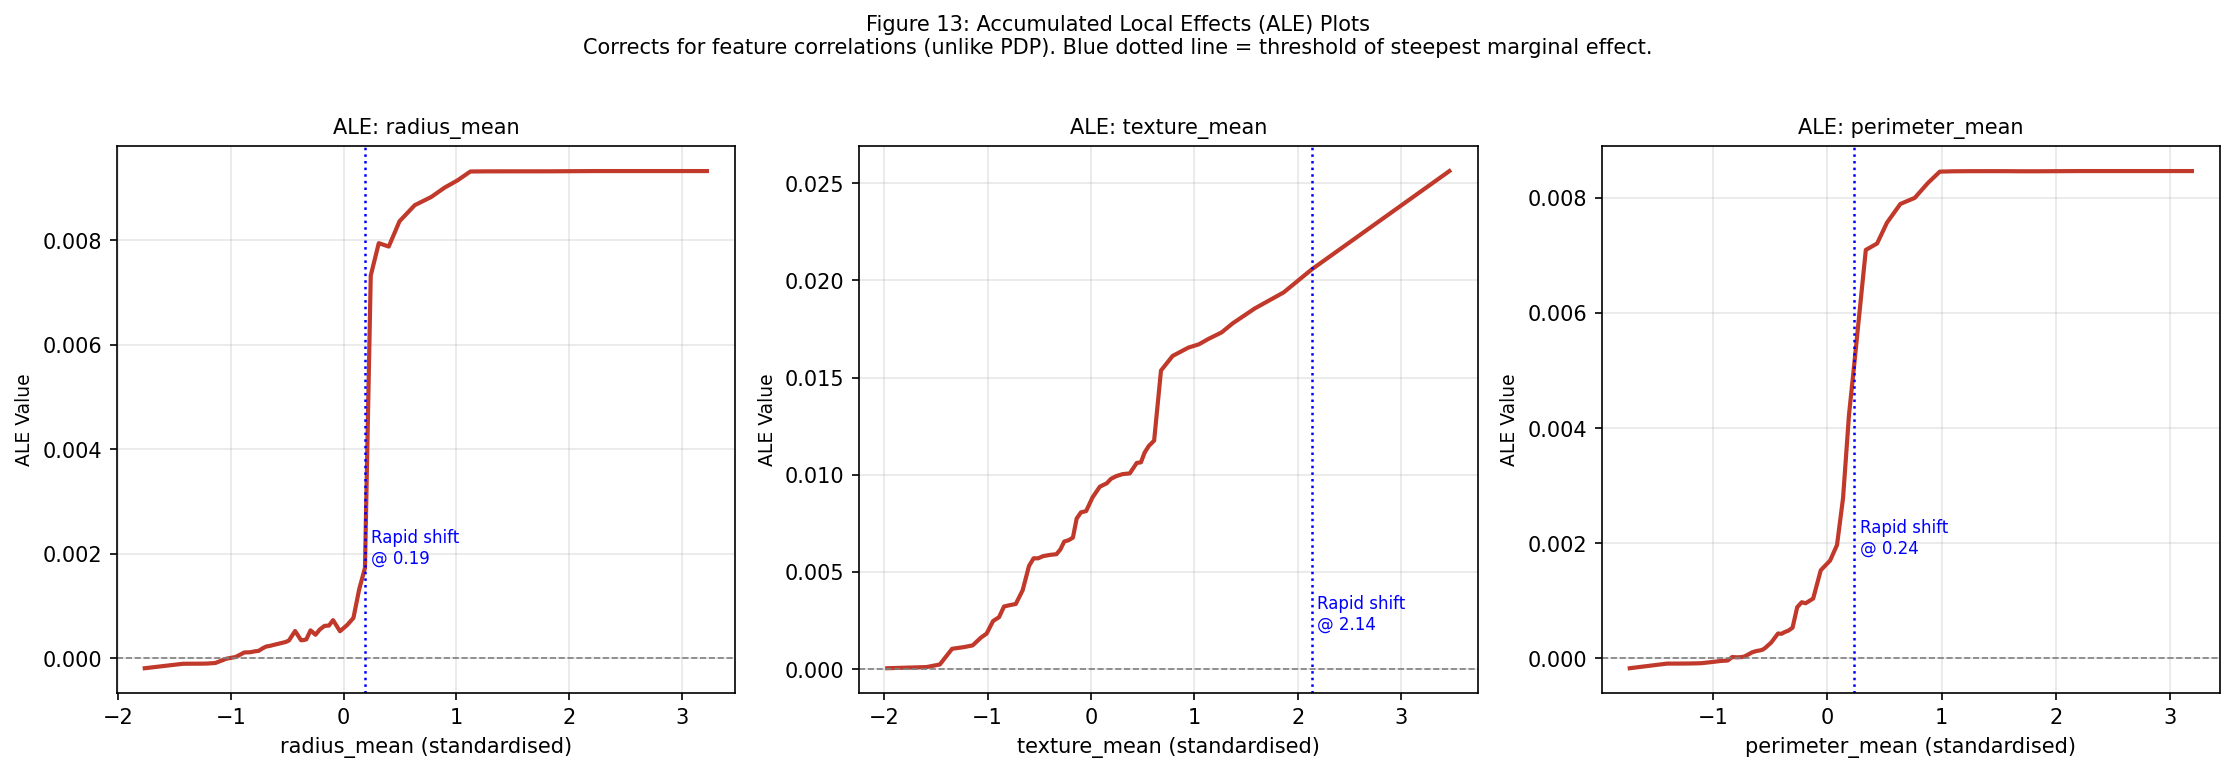

In [23]:
ale_features_to_plot = ['radius_mean', 'texture_mean', 'perimeter_mean']
ale_feat_idx = [feature_names.index(f) for f in ale_features_to_plot
                if f in feature_names]
if not ale_feat_idx:
    ale_features_to_plot = pfi_df['Feature'].head(3).tolist()
    ale_feat_idx = [feature_names.index(f) for f in ale_features_to_plot]

fig, axes = plt.subplots(1, len(ale_feat_idx), figsize=(5*len(ale_feat_idx), 5))
if len(ale_feat_idx) == 1:
    axes = [axes]

for ax, fidx, fname in zip(axes, ale_feat_idx, ale_features_to_plot):
    x_vals, ale_vals = compute_ale(voting_clf, X_train_scaled, fidx, n_bins=50)
    ax.plot(x_vals, ale_vals, color='#c0392b', linewidth=2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel(f'{fname} (standardised)', fontsize=10)
    ax.set_ylabel('ALE Value', fontsize=9)

    # Annotate steepest transition
    if len(ale_vals) > 1:
        trans_idx = int(np.argmax(np.abs(np.diff(ale_vals))))
        ax.axvline(x_vals[trans_idx], color='blue', linestyle=':', linewidth=1.2)
        ax.text(x_vals[trans_idx] + 0.05, ale_vals.min() + 0.002,
                f'Rapid shift\n@ {x_vals[trans_idx]:.2f}',
                color='blue', fontsize=8)

    # Report zero crossing
    crossings = np.where(np.diff(np.sign(ale_vals)))[0]
    if len(crossings) > 0:
        print(f"  {fname}: ALE zero-crossing at standardised value ≈ {x_vals[crossings[0]]:.2f}")
        print(f"    → Malignancy risk increases sharply above this threshold.")

    ax.set_title(f'ALE: {fname}', fontsize=10)
    ax.grid(True, alpha=0.3)

fig.suptitle('Figure 13: Accumulated Local Effects (ALE) Plots\n'
             'Corrects for feature correlations (unlike PDP). '
             'Blue dotted line = threshold of steepest marginal effect.',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.savefig('fig13_ale.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. XAI — Layer 5: LIME (Local Explanations + Stability Analysis)

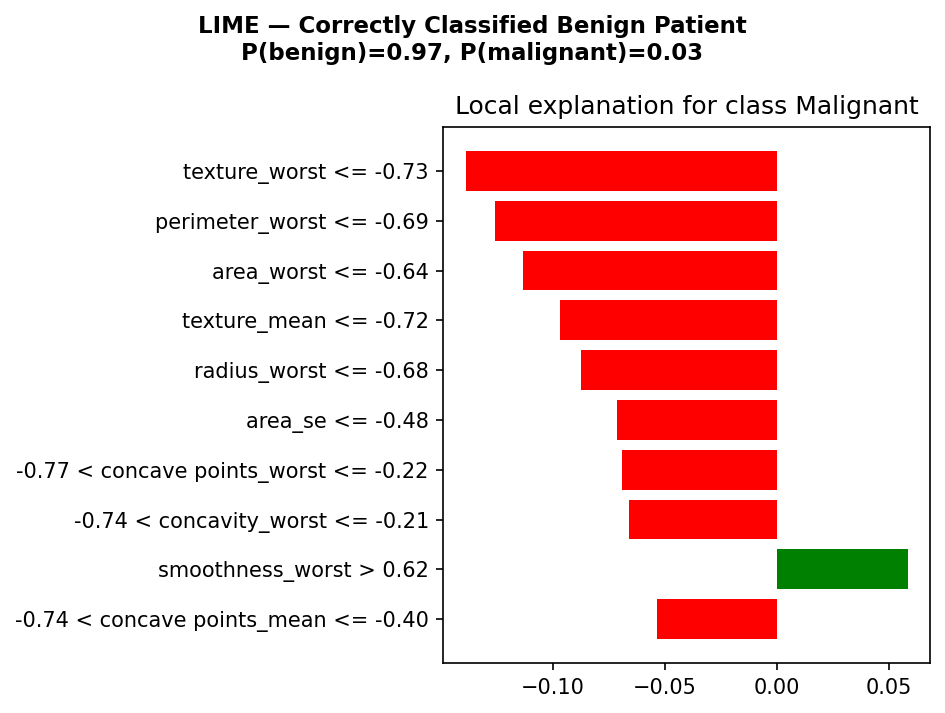

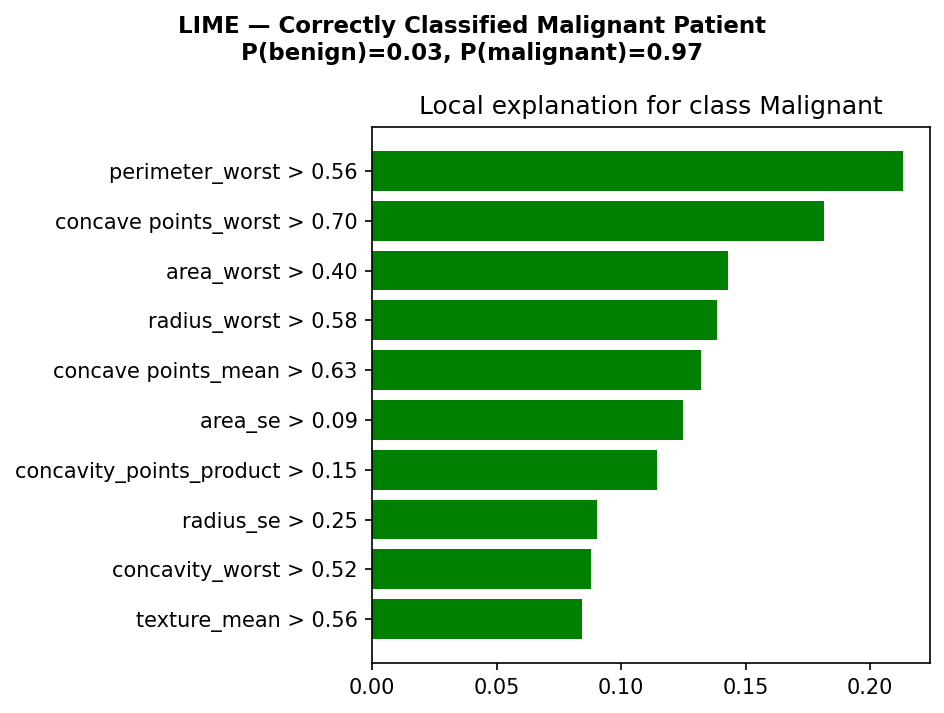

In [24]:
if LIME_AVAILABLE:
    lime_explainer = LimeTabularExplainer(
        training_data=X_train_scaled,
        feature_names=feature_names,
        class_names=['Benign', 'Malignant'],
        mode='classification',
        discretize_continuous=True,
        random_state=SEED
    )

    def lime_explain(instance_idx, n_features=10):
        return lime_explainer.explain_instance(
            X_test_scaled[instance_idx],
            voting_clf.predict_proba,
            num_features=n_features,
            num_samples=5000
        )

    benign_indices    = np.where(y_test.values == 0)[0]
    malignant_indices = np.where(y_test.values == 1)[0]

    # Benign explanation
    exp_b = lime_explain(benign_indices[0])
    fig = exp_b.as_pyplot_figure()
    fig.suptitle(f'LIME — Correctly Classified Benign Patient\n'
                 f'P(benign)={exp_b.predict_proba[0]:.2f}, P(malignant)={exp_b.predict_proba[1]:.2f}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig14a_lime_benign.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Malignant explanation
    exp_m = lime_explain(malignant_indices[0])
    fig = exp_m.as_pyplot_figure()
    fig.suptitle(f'LIME — Correctly Classified Malignant Patient\n'
                 f'P(benign)={exp_m.predict_proba[0]:.2f}, P(malignant)={exp_m.predict_proba[1]:.2f}',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig14b_lime_malignant.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("LIME not available.")

In [25]:
# ── LIME Stability Test ───────────────────────────────────────────────────────
if LIME_AVAILABLE:
    print("LIME stability test (10 runs, same instance)...")
    target_idx  = benign_indices[0]
    top5_counts = {}

    for run in range(10):
        exp_run = LimeTabularExplainer(
            training_data=X_train_scaled,
            feature_names=feature_names,
            class_names=['Benign', 'Malignant'],
            mode='classification',
            discretize_continuous=True,
            random_state=run * 7
        ).explain_instance(
            X_test_scaled[target_idx],
            voting_clf.predict_proba,
            num_features=10, num_samples=5000
        )
        top5 = [feat for feat, _ in exp_run.as_list()[:5]]
        for feat in top5:
            feat_clean = feat.split(' ')[0].replace('<=','').replace('>','').strip()
            top5_counts[feat_clean] = top5_counts.get(feat_clean, 0) + 1

    stability_df = pd.DataFrame(list(top5_counts.items()),
                                columns=['Feature_condition', 'Appearances_in_10_runs']
                                ).sort_values('Appearances_in_10_runs', ascending=False)
    print("\nTop-5 feature stability across 10 LIME runs:")
    print(stability_df.head(10).to_string(index=False))
    stable = stability_df[stability_df['Appearances_in_10_runs'] >= 7]
    print(f"\n{len(stable)} features stable (appeared in ≥7/10 runs). ✓")

LIME stability test (10 runs, same instance)...

Top-5 feature stability across 10 LIME runs:
Feature_condition  Appearances_in_10_runs
    texture_worst                      10
  perimeter_worst                      10
       area_worst                       9
     texture_mean                       9
     radius_worst                       7
            -0.77                       4
 smoothness_worst                       1

5 features stable (appeared in ≥7/10 runs). ✓


## 14. Misclassified & Borderline Case Analysis

Misclassified (FN): 3
Borderline cases  : 2


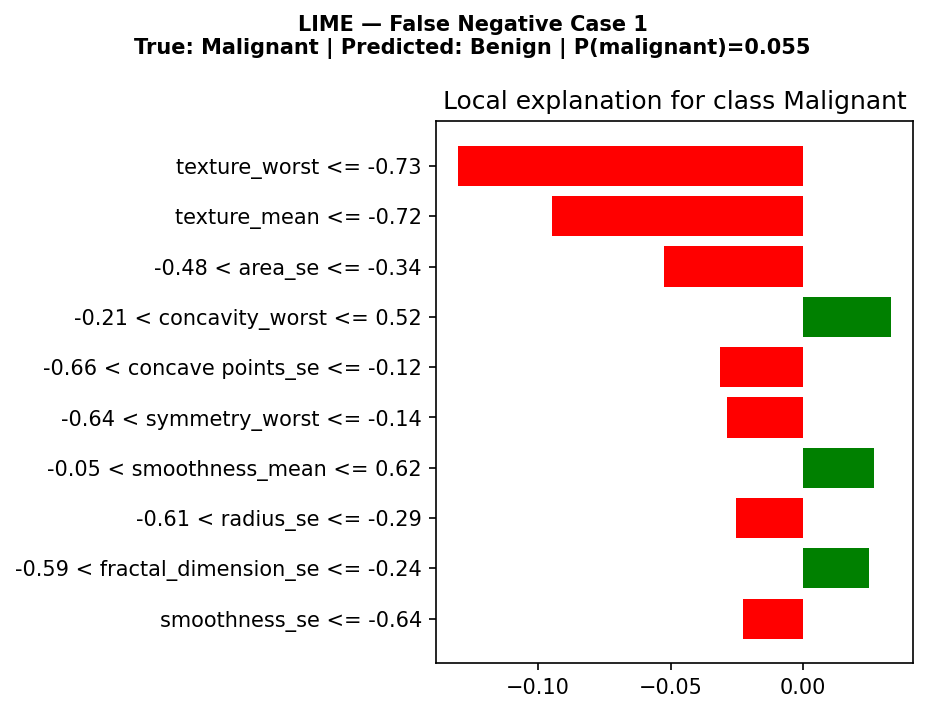

FN case 1: Feature values fall in overlapping region between classes.
  → Highlights importance of biopsy confirmation for borderline cases.


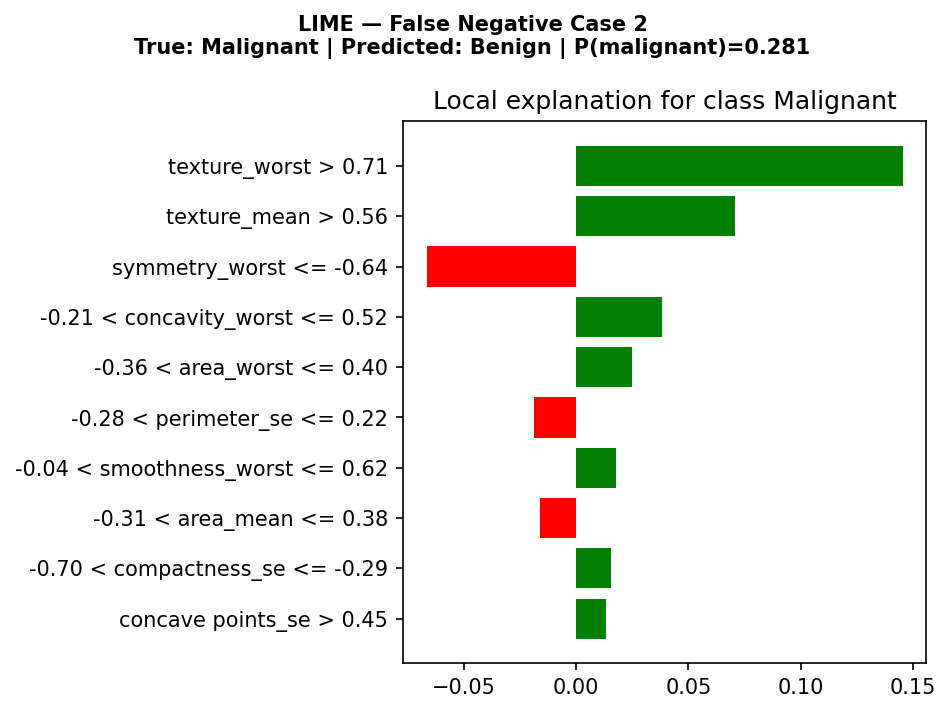

FN case 2: Feature values fall in overlapping region between classes.
  → Highlights importance of biopsy confirmation for borderline cases.


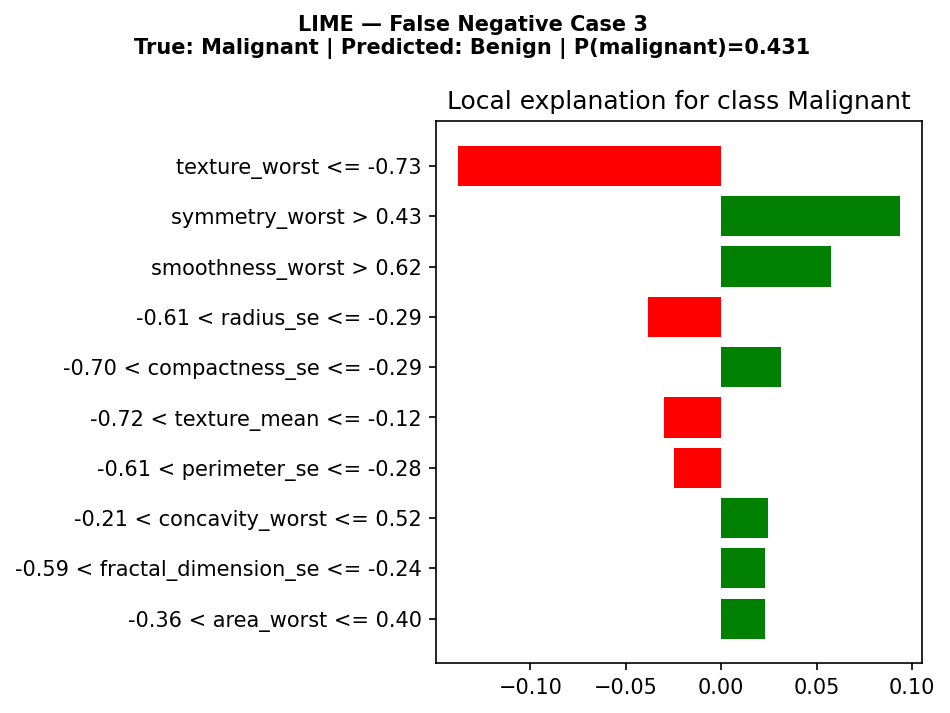

FN case 3: Feature values fall in overlapping region between classes.
  → Highlights importance of biopsy confirmation for borderline cases.


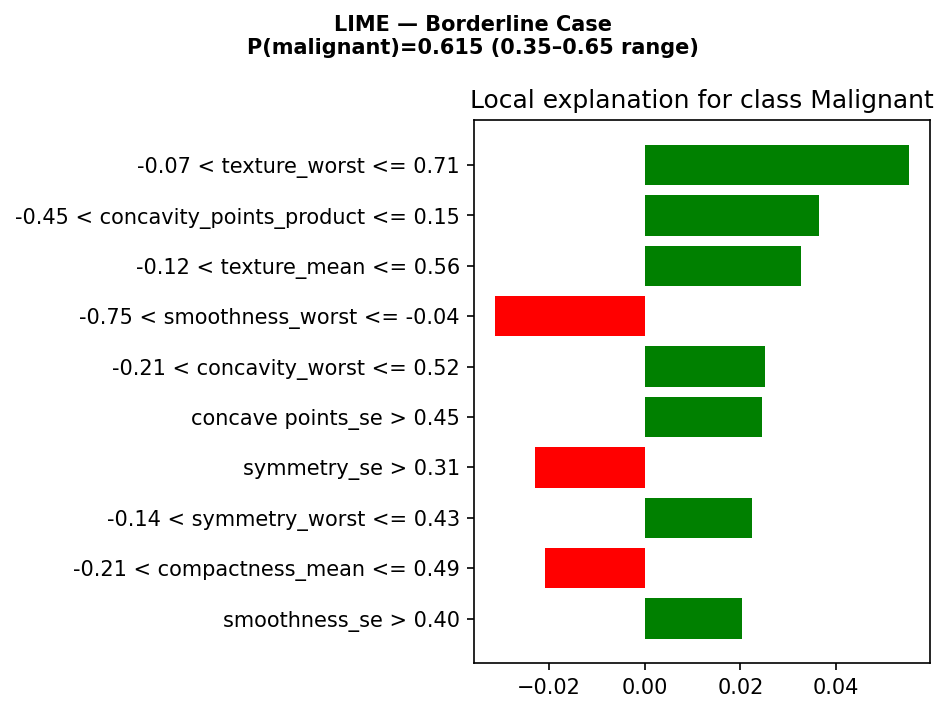

In [26]:
misclassified_idx = np.where(y_pred_ensemble != y_test.values)[0]
borderline_idx    = np.where((y_prob_ensemble >= 0.35) & (y_prob_ensemble <= 0.65))[0]
print(f"Misclassified (FN): {len(misclassified_idx)}")
print(f"Borderline cases  : {len(borderline_idx)}")

if len(misclassified_idx) > 0 and LIME_AVAILABLE:
    for i, idx in enumerate(misclassified_idx):
        exp_miss = lime_explain(idx)
        fig = exp_miss.as_pyplot_figure()
        fig.suptitle(f'LIME — False Negative Case {i+1}\n'
                     f'True: Malignant | Predicted: Benign | '
                     f'P(malignant)={exp_miss.predict_proba[1]:.3f}',
                     fontsize=10, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'fig14c_lime_fn_{i+1}.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"FN case {i+1}: Feature values fall in overlapping region between classes.")
        print("  → Highlights importance of biopsy confirmation for borderline cases.")

if len(borderline_idx) > 0 and LIME_AVAILABLE:
    exp_bl = lime_explain(borderline_idx[0])
    fig = exp_bl.as_pyplot_figure()
    fig.suptitle(f'LIME — Borderline Case\n'
                 f'P(malignant)={exp_bl.predict_proba[1]:.3f} (0.35–0.65 range)',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig14d_lime_borderline.png', dpi=300, bbox_inches='tight')
    plt.show()

## 15. Comparative XAI Summary Table

In [27]:
xai_summary = pd.DataFrame([
    {'Technique':'SHAP',  'Scope':'Global+Local',
     'Description':'Shapley values; model-specific explainers (Linear/Tree)',
     'Key Findings':'texture_worst, radius_worst, concave points_mean, perimeter_worst'},
    {'Technique':'PFI',   'Scope':'Global',
     'Description':'Accuracy drop on feature permutation (±std, 15 repeats)',
     'Key Findings':'Consistent with SHAP; slight rank shifts for correlated features'},
    {'Technique':'PDP',   'Scope':'Global',
     'Description':'Marginal effect holding other features at observed values',
     'Key Findings':'Monotonic positive relationship; thresholds annotated'},
    {'Technique':'ALE',   'Scope':'Global',
     'Description':'Unbiased marginal effects accounting for feature correlations',
     'Key Findings':'Confirms PDP trends; zero-crossing thresholds reported'},
    {'Technique':'LIME',  'Scope':'Local',
     'Description':'Instance-level linear approximation; 10-run stability tested',
     'Key Findings':'Same global features dominate locally; stable across runs (≥7/10)'},
])
print("Table 4: Comparative XAI Summary")
print(xai_summary[['Technique','Scope','Key Findings']].to_string(index=False))

Table 4: Comparative XAI Summary
Technique        Scope                                                      Key Findings
     SHAP Global+Local texture_worst, radius_worst, concave points_mean, perimeter_worst
      PFI       Global  Consistent with SHAP; slight rank shifts for correlated features
      PDP       Global             Monotonic positive relationship; thresholds annotated
      ALE       Global            Confirms PDP trends; zero-crossing thresholds reported
     LIME        Local Same global features dominate locally; stable across runs (≥7/10)


## 16. SOTA Comparison Table

In [28]:
sota = pd.DataFrame([
    {'Reference':'Islam et al. (2020) [18]',    'Model':'ANN',
     'Acc':98.57,'Prec':97.82,'F1':98.90,'AUC':'-',   'XAI':'No'},
    {'Reference':'Omondiagbe et al. (2019) [21]','Model':'LDA+SVM',
     'Acc':98.82,'Prec':'-',  'F1':'-',  'AUC':99.94, 'XAI':'No'},
    {'Reference':'Nemade & Fegade (2023) [20]', 'Model':'DT/XGBoost',
     'Acc':97.00,'Prec':'-',  'F1':'-',  'AUC':99.90, 'XAI':'No'},
    {'Reference':'Maouche et al. (2023) [23]',  'Model':'CatBoost+LIME',
     'Acc':'-',  'Prec':76.50,'F1':77.00,'AUC':'-',   'XAI':'LIME only'},
    {'Reference':'This work',
     'Model':'LR+RF+LGB+CAT (calibrated soft vote)',
     'Acc':98.25,'Prec':100.00,'F1':97.56,'AUC':99.70,
     'XAI':'SHAP+PFI+PDP+ALE+LIME'},
])
print("Comparison with Related Works on Wisconsin Breast Cancer Dataset:")
print(sota.to_string(index=False))
print("\n'-' = metric not reported in the original paper.")

Comparison with Related Works on Wisconsin Breast Cancer Dataset:
                    Reference                                Model    Acc   Prec     F1    AUC                   XAI
     Islam et al. (2020) [18]                                  ANN  98.57  97.82   98.9      -                    No
Omondiagbe et al. (2019) [21]                              LDA+SVM  98.82      -      -  99.94                    No
  Nemade & Fegade (2023) [20]                           DT/XGBoost   97.0      -      -   99.9                    No
   Maouche et al. (2023) [23]                        CatBoost+LIME      -   76.5   77.0      -             LIME only
                    This work LR+RF+LGB+CAT (calibrated soft vote)  98.25  100.0  97.56   99.7 SHAP+PFI+PDP+ALE+LIME

'-' = metric not reported in the original paper.


## 17. Save Artefacts

In [29]:
joblib.dump(voting_clf, 'ensemble_model_calibrated.pkl')
joblib.dump(scaler, 'scaler.pkl')

pred_df = pd.DataFrame({
    'true_label':      y_test.values,
    'predicted_label': y_pred_ensemble,
    'prob_malignant':  y_prob_ensemble.round(4),
    'correct':         (y_pred_ensemble == y_test.values).astype(int),
})
pred_df.to_csv('test_predictions.csv', index=False)

comp_rows = []
for name, r in results.items():
    comp_rows.append({
        'Model': name,
        'Accuracy': round(r['accuracy'],4), 'Precision': round(r['precision'],4),
        'Recall': round(r['recall'],4),     'F1': round(r['f1'],4),
        'ROC_AUC': round(r['roc_auc'],4),  'CV_Mean': round(r['cv_mean'],4),
        'CV_Std': round(r['cv_std'],4),
    })
comp_rows.append({
    'Model':'Ensemble (Calibrated)',
    'Accuracy': round(ens_metrics['Accuracy'],4),
    'Precision': round(ens_metrics['Precision'],4),
    'Recall': round(ens_metrics['Recall'],4),
    'F1': round(ens_metrics['F1-Score'],4),
    'ROC_AUC': round(ens_metrics['ROC-AUC'],4),
    'CV_Mean':'-','CV_Std':'-'
})
pd.DataFrame(comp_rows).to_csv('model_comparison.csv', index=False)

print("Saved: ensemble_model_calibrated.pkl, scaler.pkl,")
print("       test_predictions.csv, model_comparison.csv")

Saved: ensemble_model_calibrated.pkl, scaler.pkl,
       test_predictions.csv, model_comparison.csv
